# Import all kind of stuff

In [1]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

# btk - dos
for Gamma = 0.0, Gamma/Delta = 0.05

In [2]:
Delta_meV = 0.180
gamma_meV = 0.0
T_K = 0.0

tau = np.array([1.0, 0.66, 0.33, 0.1])
V_mV = np.linspace(0, 2.5 * Delta_meV, 501)

I = np.full((tau.shape[0], V_mV.shape[0]), np.nan)
dIdV = np.copy(I)
N_1e = np.copy(I)
N_2e = np.copy(I)
for i, tau_i in enumerate(tau):
    Z = sc.get_Z_btk(tau_i)
    A, B = sc.get_AB_btk(
        E_meV=V_mV,
        Delta_meV=Delta_meV,
        Z=Z,
        gamma_meV=gamma_meV,
    )
    N_1e[i, :] = (1 - A - B) / tau_i
    N_2e[i, :] = 2 * A / tau_i

    I_nA = sc.get_I_btk_nA(
        V_mV=V_mV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    )[:, 0]
    dIdV[i, :] = np.gradient(I_nA, V_mV, axis=0) / G0_muS / tau_i
    I[i, :] = I_nA / (G0_muS * tau_i * Delta_meV)

/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/mar/models/btk.py:36: RuntimeWarning: overflow encountered in square
  etta2 = np.square(etta)
/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/mar/models/btk.py:39: RuntimeWarning: overflow encountered in square
  gamma2 = np.square(alpha + Z2 * diff) + np.square(etta * (2.0 * Z2 + 1.0))
/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/mar/models/btk.py:41: RuntimeWarning: invalid value encountered in divide
  A = np.sqrt(np.abs((alpha2 + etta2) * (beta2 + etta2))) / gamma2
/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/mar/models/btk.py:42: RuntimeWarning: overflow encountered in square
  term1 = np.square(diff * Z - 2.0 * etta)
/Users/oliver/Documents/cryolab/superconductivity/superconductivity/models/mar/models/btk.py:44: RuntimeWarning: invalid value encountered in multiply
  B = (Z2 * (term1 + term2)) / gamma2
/Users/oliver/Doc

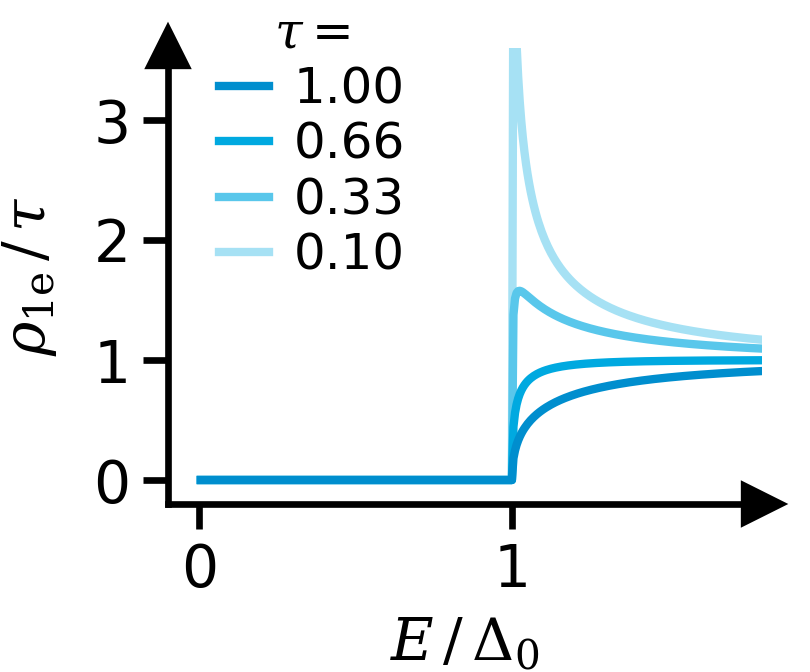

In [3]:
fig, ax = sc.get_figure(figsize=(1.35, 1.12))

for i, tau_i in enumerate(tau):
    ax.plot(
        V_mV / Delta_meV,
        N_1e[i, :],
        color=sc.seeblau[i],
        zorder=10 - i,
        label=f"{tau_i:.2f}",
    )

ax.set_xlim(-0.1, 1.8)
ax.set_ylim(-0.2, 3.6)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1])

ax.legend(
    title="$\\tau = $",
    handlelength=1.0,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    bbox_to_anchor=(0.45, 1.15),
    # bbox_to_anchor=(1.0, 1.15),
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.15,  # reduces vertical spacing between items
    handletextpad=0.5,  # reduces spacing between line and label
)

ylabel = "$\\rho_\\mathrm{1e}\\,/\\,\\tau$"
xlabel = "$E\\,/\\,\\Delta_0$"
title = "theory/meso/btk-1e-dos"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

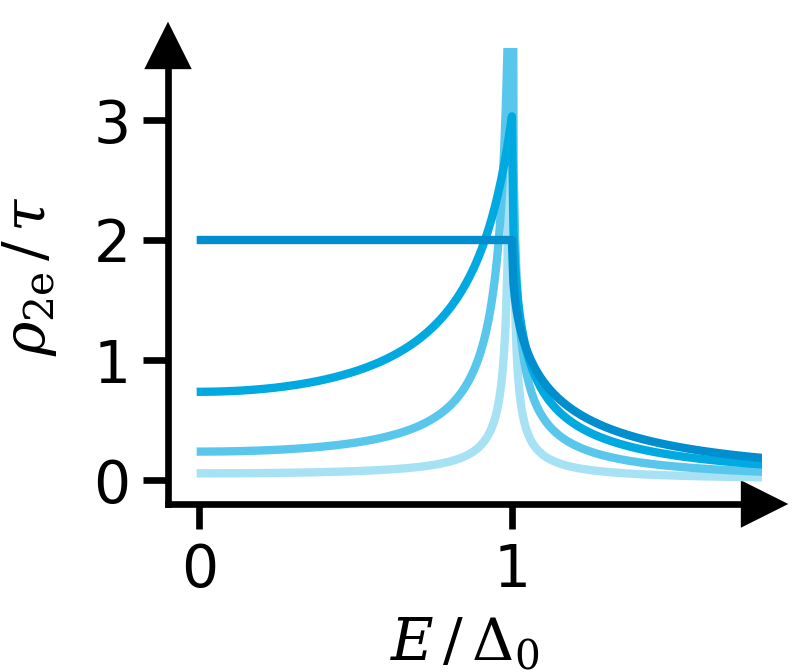

In [4]:
fig, ax = sc.get_figure(figsize=(1.35, 1.12))

for i, tau_i in enumerate(tau):
    ax.plot(
        V_mV / Delta_meV,
        N_2e[i, :],
        color=sc.seeblau[i],
        zorder=10 - i,
        label=f"{tau_i:.1f}",
    )

ax.set_xlim(-0.1, 1.8)
ax.set_ylim(-0.2, 3.6)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1])

ylabel = "$\\rho_\\mathrm{2e}\\,/\\,\\tau$"
xlabel = "$E\\,/\\,\\Delta_0$"
title = "theory/meso/btk-2e-dos"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

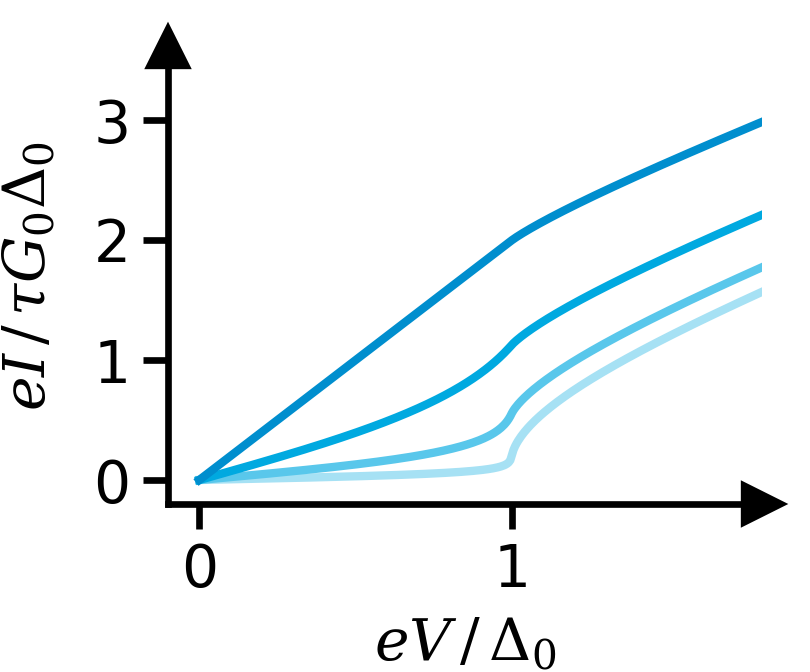

In [5]:
fig, ax = sc.get_figure(figsize=(1.35, 1.12))

for i, tau_i in enumerate(tau):
    ax.plot(
        V_mV / Delta_meV,
        I[i, :],
        color=sc.seeblau[i],
        zorder=10 - i,
        label=f"{tau_i:.1f}",
    )

ax.set_xlim(-0.1, 1.8)
ax.set_ylim(-0.2, 3.6)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1])

ylabel = "$eI\\,/\\,\\tau G_0\\Delta_0$"
xlabel = "$eV\\,/\\,\\Delta_0$"
title = "theory/meso/btk-iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

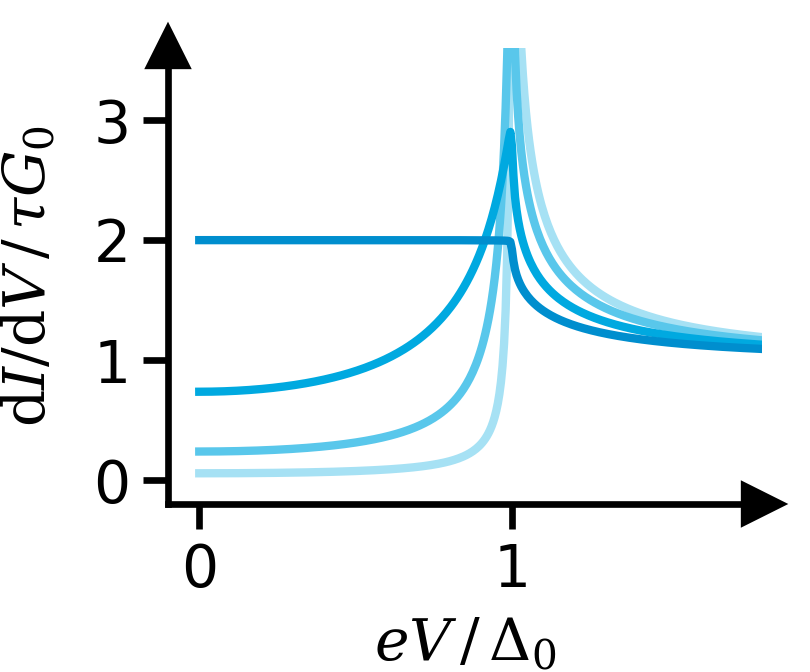

In [6]:
fig, ax = sc.get_figure(figsize=(1.35, 1.12))

for i, tau_i in enumerate(tau):
    ax.plot(
        V_mV / Delta_meV,
        dIdV[i, :],
        color=sc.seeblau[i],
        zorder=10 - i,
        label=f"{tau_i:.1f}",
    )

ax.set_xlim(-0.1, 1.8)
ax.set_ylim(-0.2, 3.6)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1])

ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,\\tau G_0$"
xlabel = "$eV\\,/\\,\\Delta_0$"
title = "theory/meso/btk-didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# ABS

In [7]:
Delta_meV = 0.180
T_K = 0.0

tau = np.array([1.0, 0.95, 0.66, 0.33, 0.1])
phi = np.linspace(0, 2 * np.pi, 361)

E_abs = np.zeros((tau.shape[0], phi.shape[0]))
E_abs_meV = np.copy(E_abs)
I_abs = np.copy(E_abs)
I_abs_nA = np.copy(E_abs)

for i_tau, tau_i in enumerate(tau):
    E_abs[i_tau, :] = sc.get_E_abs(
        phi=phi,
        tau=tau_i,
    )
    I_abs[i_tau, :] = sc.get_cpr_abs(
        phi=phi,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
    )
I_abs[0, 180] = np.nan

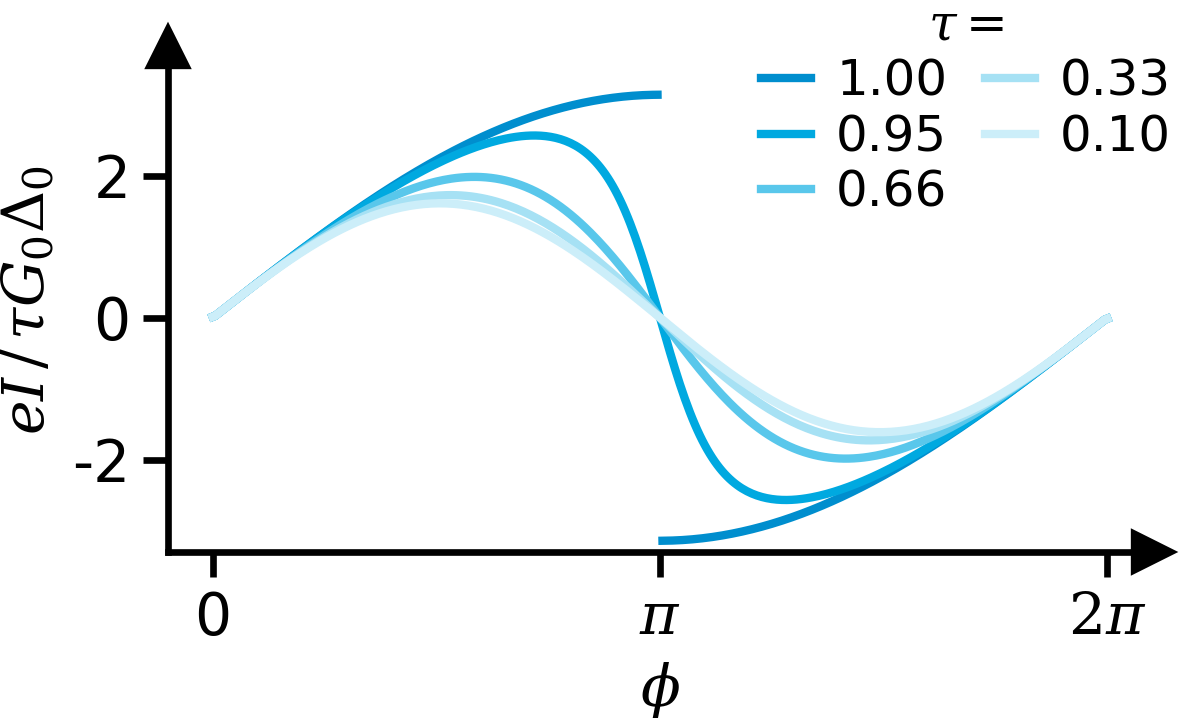

In [8]:
fig, ax = sc.get_figure(figsize=(2, 1.2))
for i, tau_i in enumerate(tau):
    ax.plot(phi, I_abs[i, :] / tau_i, "-", color=sc.seeblau[i], label=f"{tau_i:.2f}")

ax.set_xticks([0, np.pi, np.pi * 2], labels=["0", "$\\pi$", "$2\\pi$"])
ax.set_ylim(-3.3, 3.8)

ax.legend(
    title="$\\tau = $",
    handlelength=1.0,
    loc="upper right",
    ncols=2,
    columnspacing=0.75,
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    bbox_to_anchor=(1.05, 1.15),
    # bbox_to_anchor=(1.0, 1.15),
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.15,  # reduces vertical spacing between items
    handletextpad=0.5,  # reduces spacing between line and label
)

ylabel = "$eI\\,/\\,\\tau G_0 \\Delta_0$"
xlabel = "$\\phi$"
title = "theory/meso/abs-Iphi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

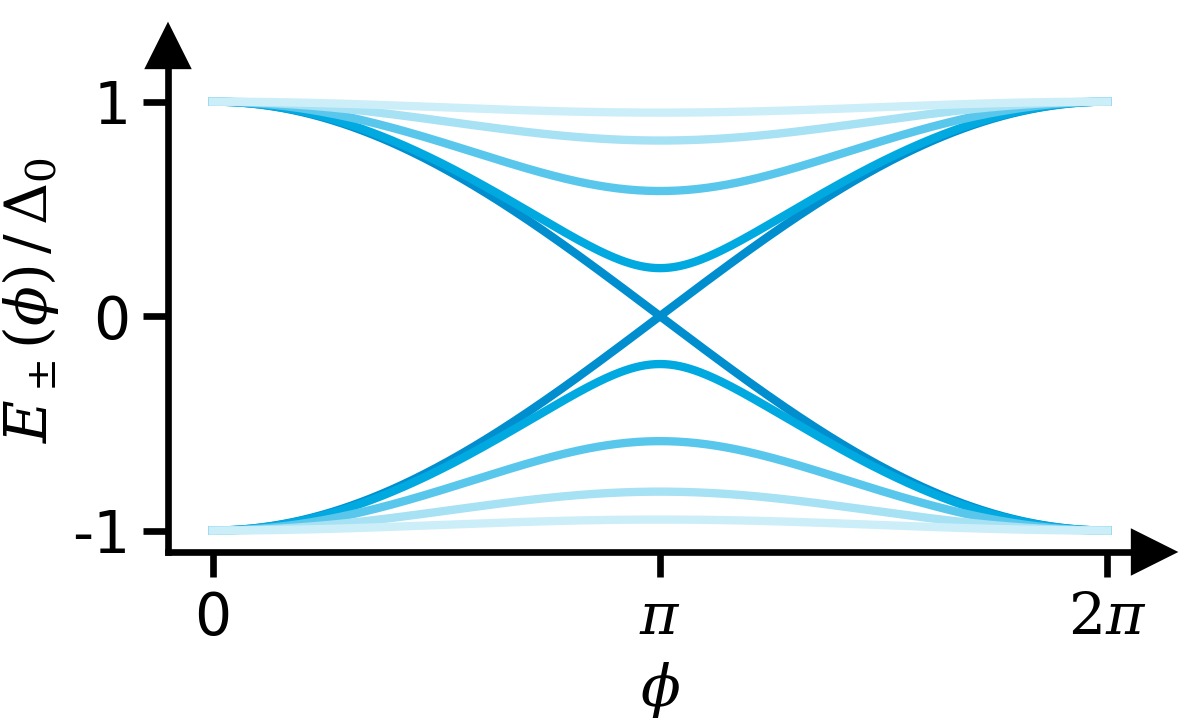

In [9]:
fig, ax = sc.get_figure(figsize=(2, 1.2))
for i, tau_i in enumerate(tau):
    ax.plot(phi, E_abs[i, :], color=sc.seeblau[i])
    ax.plot(phi, -E_abs[i, :], color=sc.seeblau[i])

ax.set_xticks([0, np.pi, np.pi * 2], labels=["0", "$\\pi$", "$2\\pi$"])
ax.set_ylim(-1.1, 1.25)

ylabel = "$E_\\pm(\\phi)\\,/\\,\\Delta_0$"
xlabel = "$\\phi$"
title = "theory/meso/abs-Ephi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# Multichannel Contact

In [10]:
tau = np.linspace(0, 1, 101)
phi = np.linspace(0, 1, 361)
phi *= 2 * np.pi

GN_G0 = 1.0
T_K = 0.0
n_phi = 501

rho = sc.get_rho(tau=tau, GN_G0=GN_G0)
CPR_AB = sc.get_cpr_ab(phi=phi, Delta_meV=Delta_meV, GN_G0=GN_G0, T_K=T_K)
CPR_ABS = sc.get_cpr_abs(phi=phi, Delta_meV=Delta_meV, tau=GN_G0, T_K=T_K)
CPR_KO2 = sc.get_cpr_ko2(phi=phi, Delta_meV=Delta_meV, GN_G0=GN_G0, T_K=T_K)
CPR_KO1 = sc.get_cpr_ko1(phi=phi, Delta_meV=Delta_meV, GN_G0=GN_G0, T_K=T_K)

TC_K = sc.get_Tc_K(Delta_meV=Delta_meV)
T = np.linspace(0, 1, 101)
T_K = T * TC_K

I_C_AB = sc.get_IcT_ab(T_K=T_K, Delta_meV=Delta_meV, GN_G0=GN_G0)
I_C_ABS = sc.get_IcT_abs(T_K=T_K, Delta_meV=Delta_meV, tau=GN_G0, n_phi=n_phi)
I_C_KO1 = sc.get_IcT_ko1(T_K=T_K, Delta_meV=Delta_meV, GN_G0=GN_G0, n_phi=n_phi)
I_C_KO2 = sc.get_IcT_ko2(T_K=T_K, Delta_meV=Delta_meV, GN_G0=GN_G0, n_phi=n_phi)

CPR_KO2[180] = np.nan

100%|██████████| 101/101 [00:51<00:00,  1.98it/s]


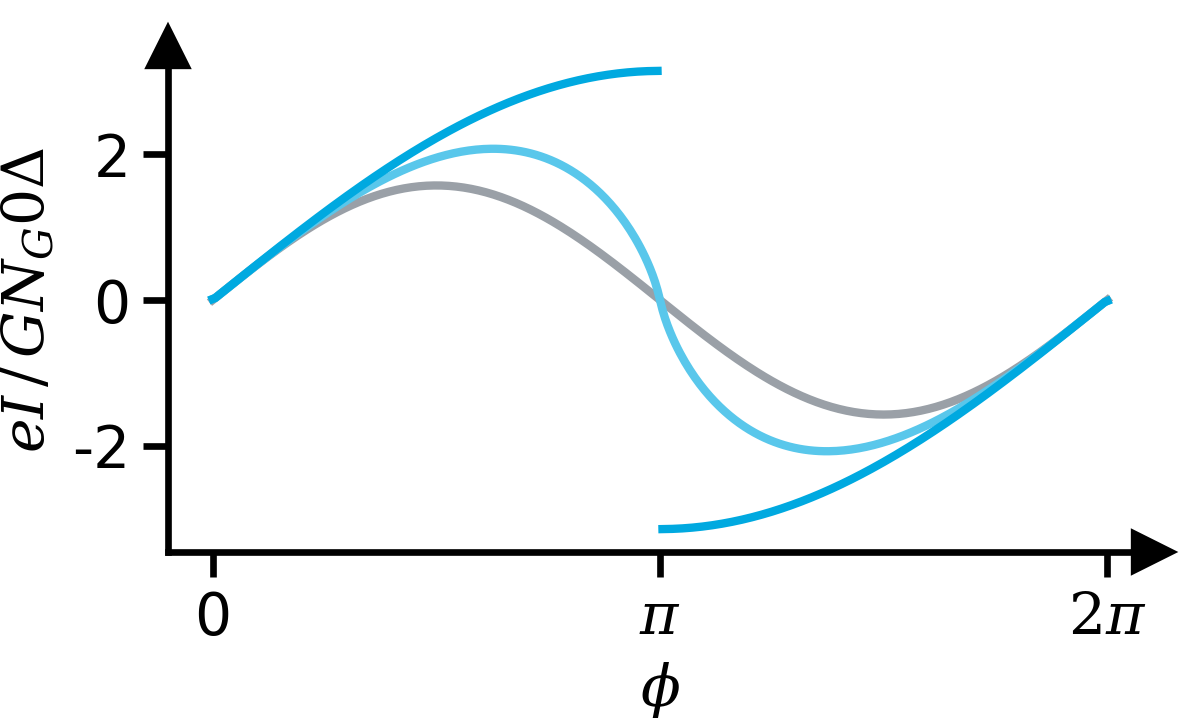

In [11]:
fig, ax = sc.get_figure(figsize=(2.0, 1.2))

ax.plot(phi, CPR_AB, color=sc.seegrau65, label="AB")
ax.plot(phi, CPR_KO1, color=sc.seeblau65, label="KO1")
ax.plot(phi, CPR_KO2, color=sc.seeblau100, label="KO2")

ax.set_xticks([0, np.pi, np.pi * 2], labels=["0", "$\\pi$", "$2\\pi$"])

ylabel = "$eI\\,/\\,GN_G0 \\Delta$"
xlabel = "$\\phi$"
title = "theory/meso/ko-cpr"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

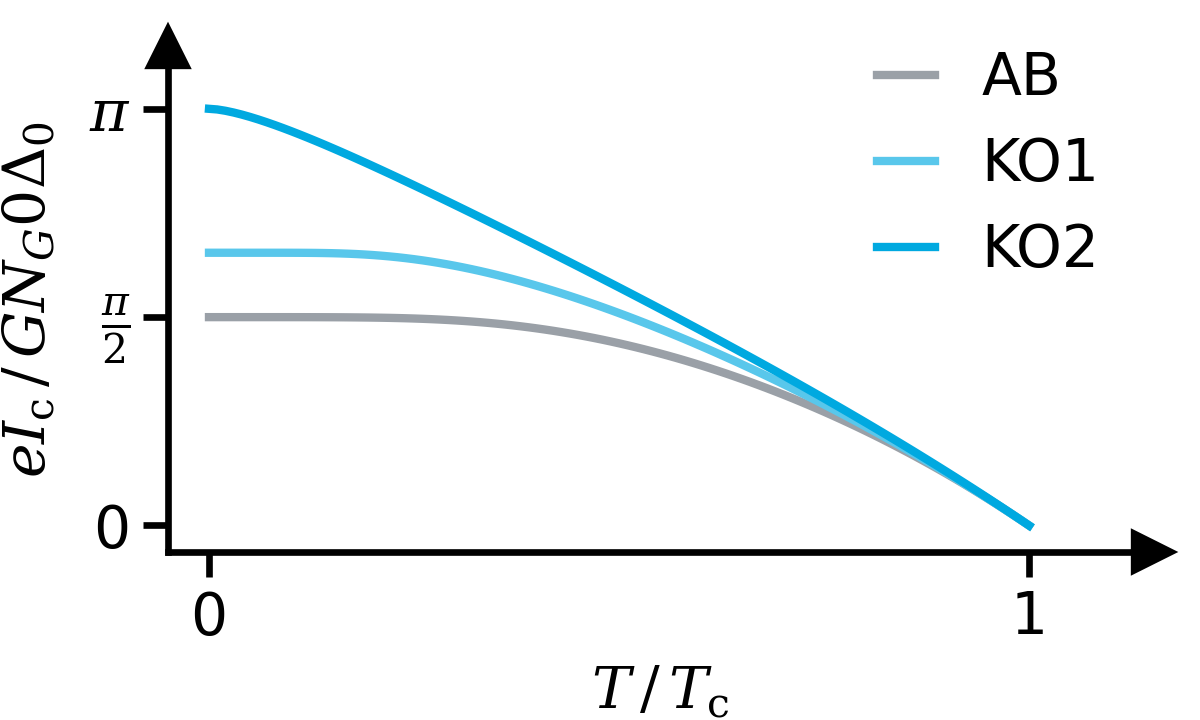

In [12]:
fig, ax = sc.get_figure(figsize=(2.0, 1.2))

ax.plot(T, I_C_AB, color=sc.seegrau65, label="AB")
ax.plot(T, I_C_KO1, color=sc.seeblau65, label="KO1")
ax.plot(T, I_C_KO2, color=sc.seeblau100, label="KO2")

ax.legend()
ax.set_xlim(-0.05, 1.15)
ax.set_xticks([0, 1])
ax.set_ylim(-0.2, 3.6)
ax.set_yticks([0, np.pi / 2, np.pi], labels=["0", "$\\frac{\\pi}{2}$", "$\\pi$"])

ax.legend(
    handlelength=1.0,
    loc="upper right",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=1.0,
    bbox_to_anchor=(1.0, 1.1),
)

ylabel = "$eI_\\mathrm{c}\\,/\\,GN_G0 \\Delta_0$"
xlabel = "$T\\,/\\,T_\\mathrm{c}$"
title = "theory/meso/ko-ic"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

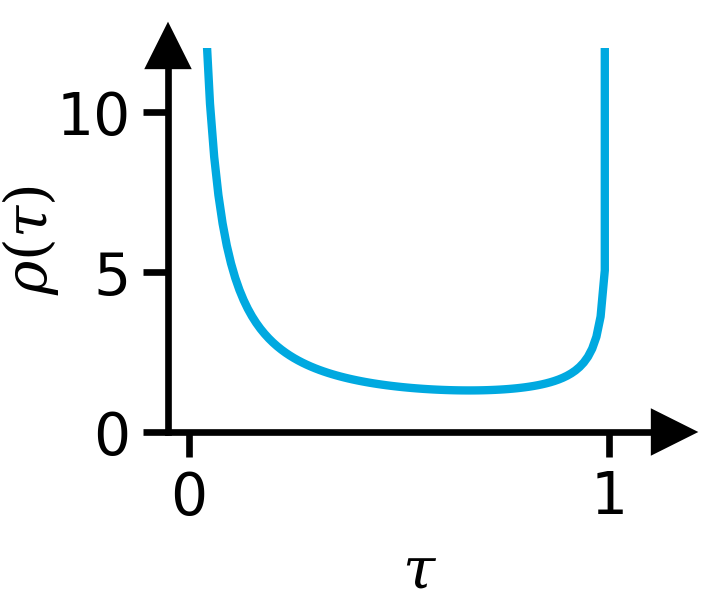

In [13]:
fig, ax = sc.get_figure(figsize=(1.2, 1.0))

ax.plot(tau, rho, color=sc.seeblau100)

ax.set_ylim(0, 12)
ax.set_yticks([0, 5, 10])
ax.set_xlim(-0.05, 1.15)
ax.set_xticks([0, 1])

ylabel = "$\\rho(\\tau)$"
xlabel = "$\\tau$"
title = "theory/meso/ko-rho"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# ha-current

In [14]:
V = np.linspace(0, 2.5, 1001)
from scipy.signal import savgol_filter as savgol

tau = np.array([1.0, 0.9, 0.66, 0.33, 0.1])
tau = np.flip(tau)
Delta_meV = 0.18
T_K = 0.0
gamma_meV = 1e-5
V_mV = V * Delta_meV

I = np.full((tau.shape[0], V_mV.shape[0]), np.nan)
dIdV = np.copy(I)

for i, tau_i in enumerate(tau):
    I_temp = sc.get_I_ha_nA(
        V_mV=V_mV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
        gamma_meV_min=1e-7,
    ) / (G0_muS * Delta_meV)

    if tau_i == 1.0:
        mask = I_temp < 2.0
        non_mask = np.logical_not(mask)

        I_temp = savgol(I_temp, 5, 1)
        I_temp[mask] = np.nan
        dIdV_temp = np.gradient(I_temp[non_mask], V_mV[non_mask] / Delta_meV)
        dIdV_temp[0] = 1e12
        dIdV_temp = savgol(dIdV_temp, 30, 1)
        I[i, :] = I_temp
        dIdV[i, non_mask] = dIdV_temp
    else:
        I[i, :] = I_temp
        dIdV[i, :] = np.gradient(I[i, :], V_mV / Delta_meV)
        dIdV[i, :] = savgol(dIdV[i, :], 5, 1)
# dIdV[0, 0] = 0

colors = [
    sc.seeblau100,
    sc.seegrau100,
    sc.seeblau65,
    sc.seegrau65,
    sc.seeblau35,
    sc.seegrau35,
    sc.seeblau20,
    sc.seegrau20,
]
seeblaus = [
    sc.seeblau120,
    sc.seeblau80,
    sc.seeblau65,
    sc.seeblau35,
    sc.seeblau20,
]
figsize = (2.0, 1.2)

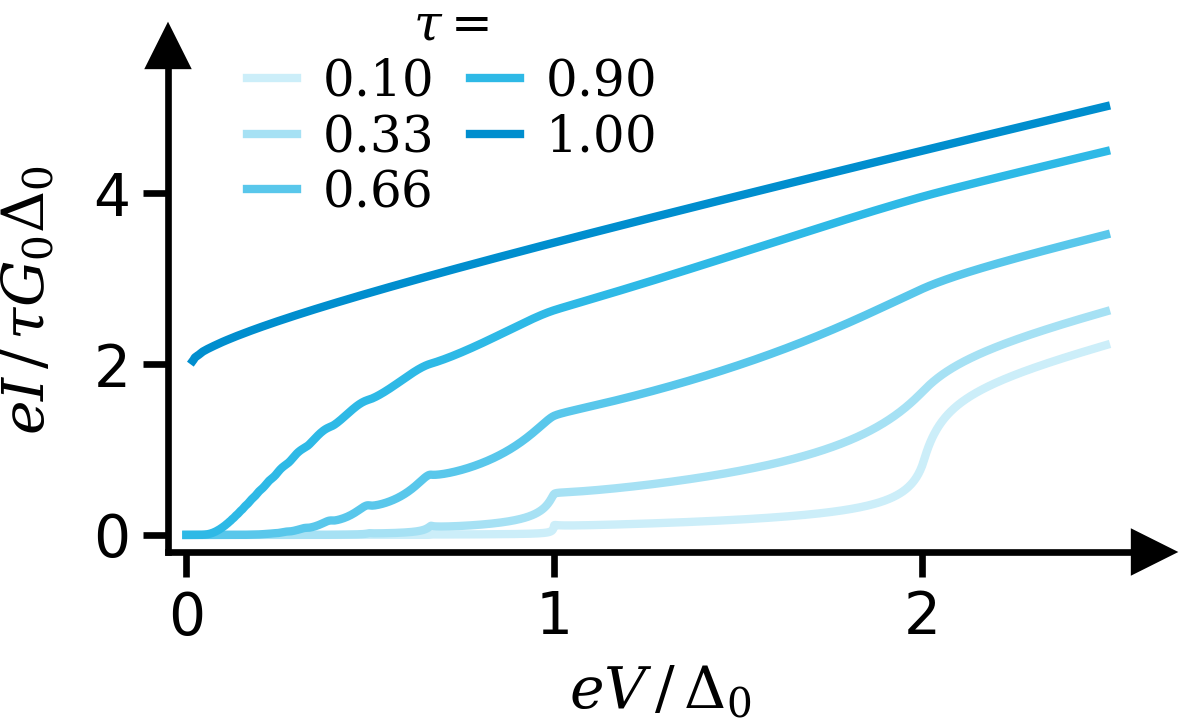

In [15]:
fig, ax = sc.get_figure(figsize=figsize)

for i, tau_i in enumerate(tau):
    ax.plot(
        V_mV / Delta_meV,
        I[i, :] / tau_i,
        color=seeblaus[4 - i],
        label=f"${tau_i:.2f}$",
        zorder=i,
    )

ax.set_ylim(-0.2, 5.7)
ax.set_xlim(-0.05, None)

ax.legend(
    title="$\\tau = $",
    loc="upper left",
    handlelength=1.0,
    columnspacing=0.75,
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    bbox_to_anchor=(0.05, 1.15),
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.15,  # reduces vertical spacing between items
    handletextpad=0.5,  # reduces spacing between line and label
)

ylabel = "$eI\\,/\\,\\tau G_0\\Delta_0$"
xlabel = "$eV\\,/\\,\\Delta_0$"
title = f"theory/meso/ha-iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

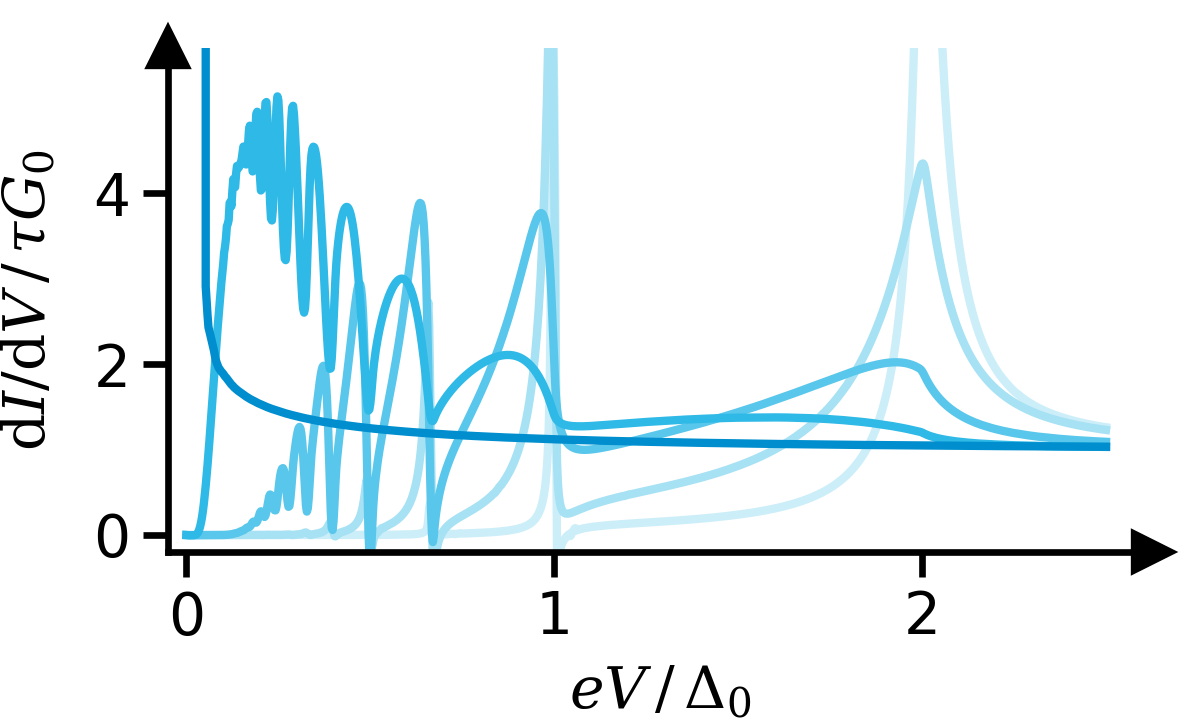

In [16]:
fig, ax = sc.get_figure(figsize=figsize)

for i, tau_i in enumerate(tau):
    ax.plot(
        V_mV / Delta_meV,
        dIdV[i, :] / tau_i,
        color=seeblaus[4 - i],
        zorder=i,
        label=f"$\\tau={tau_i:.2f}$",
    )

ax.set_ylim(-0.2, 5.7)
ax.set_xlim(-0.05, None)

ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,\\tau G_0$"
xlabel = "$eV\\,/\\,\\Delta_0$"
title = f"theory/meso/ha-didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

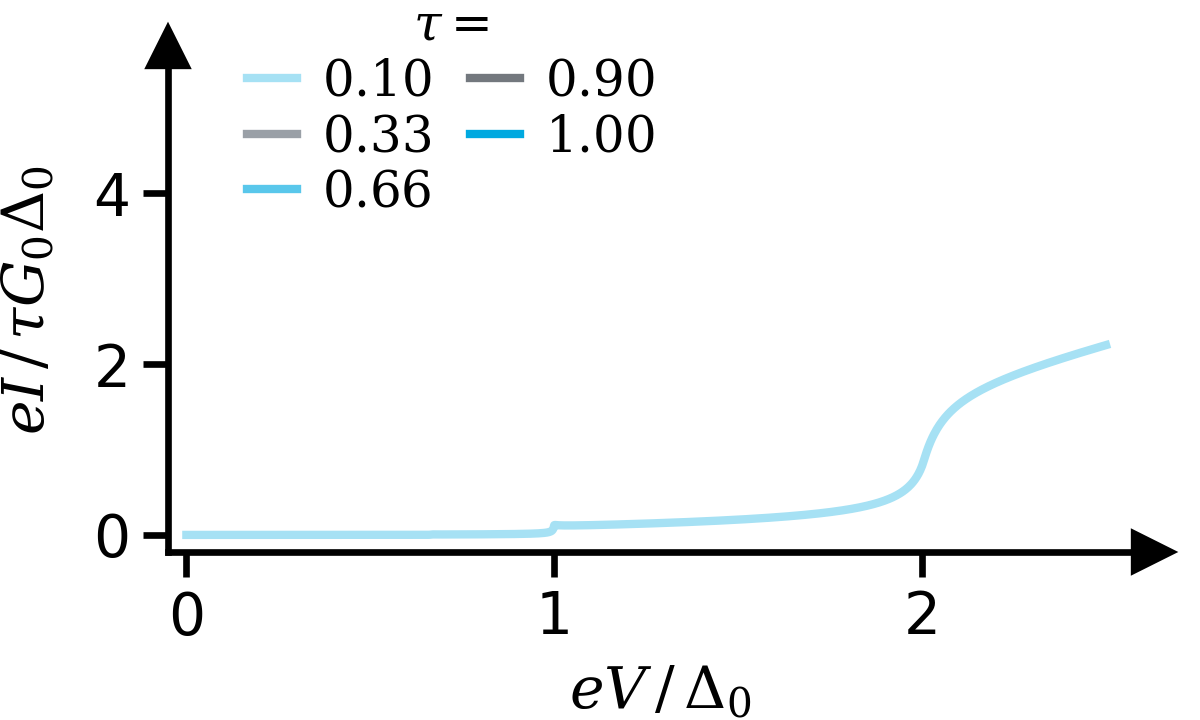

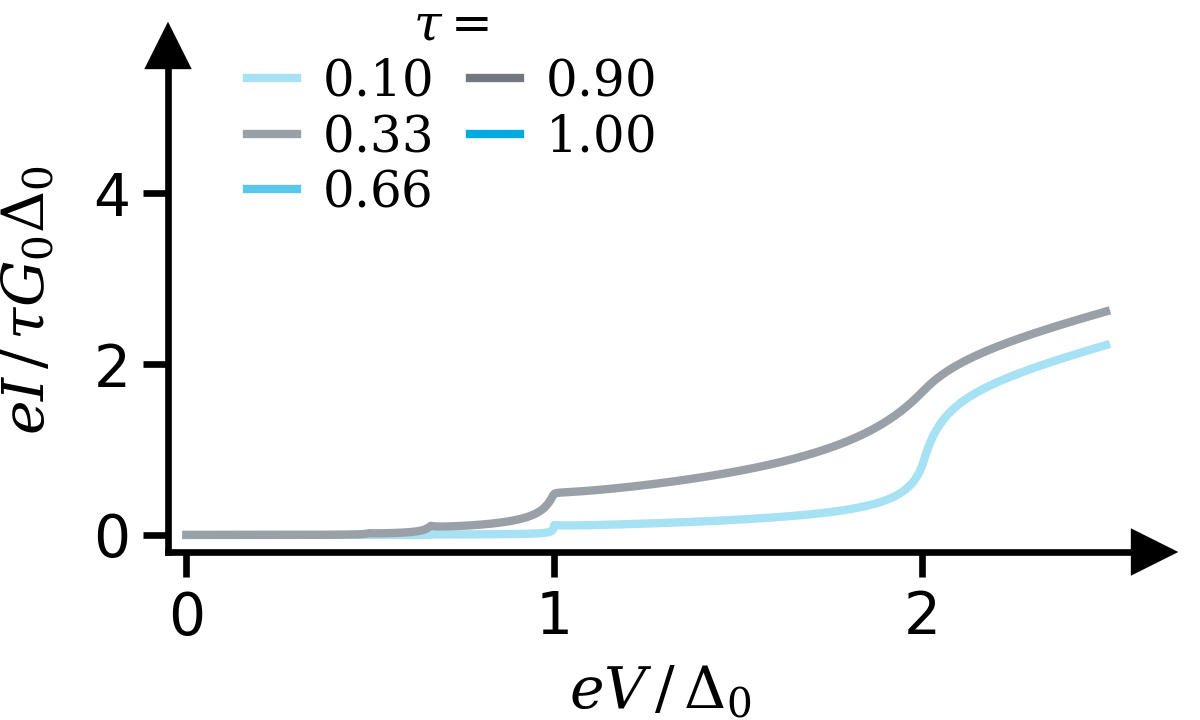

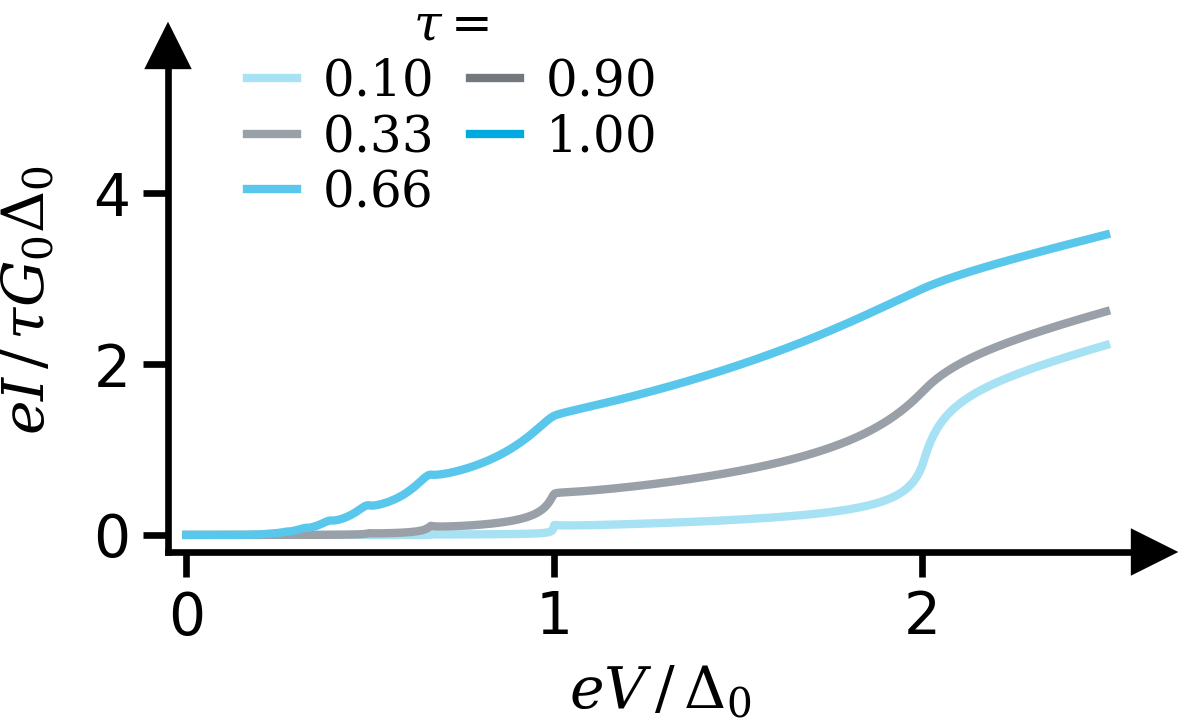

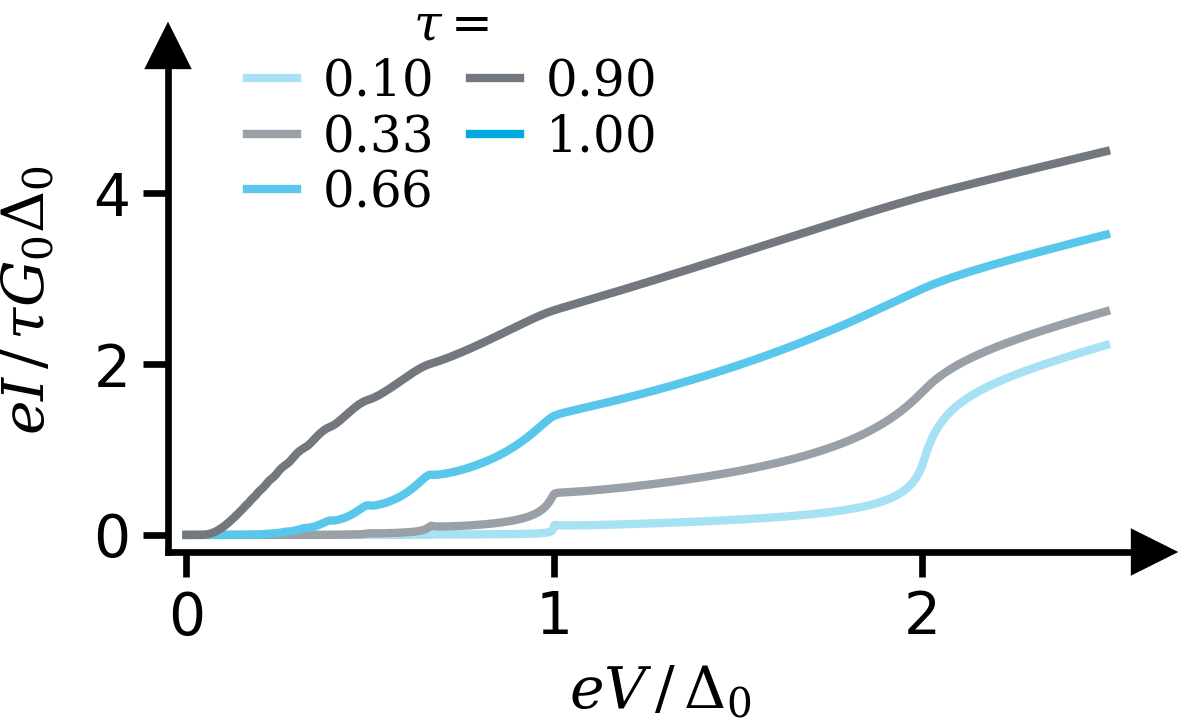

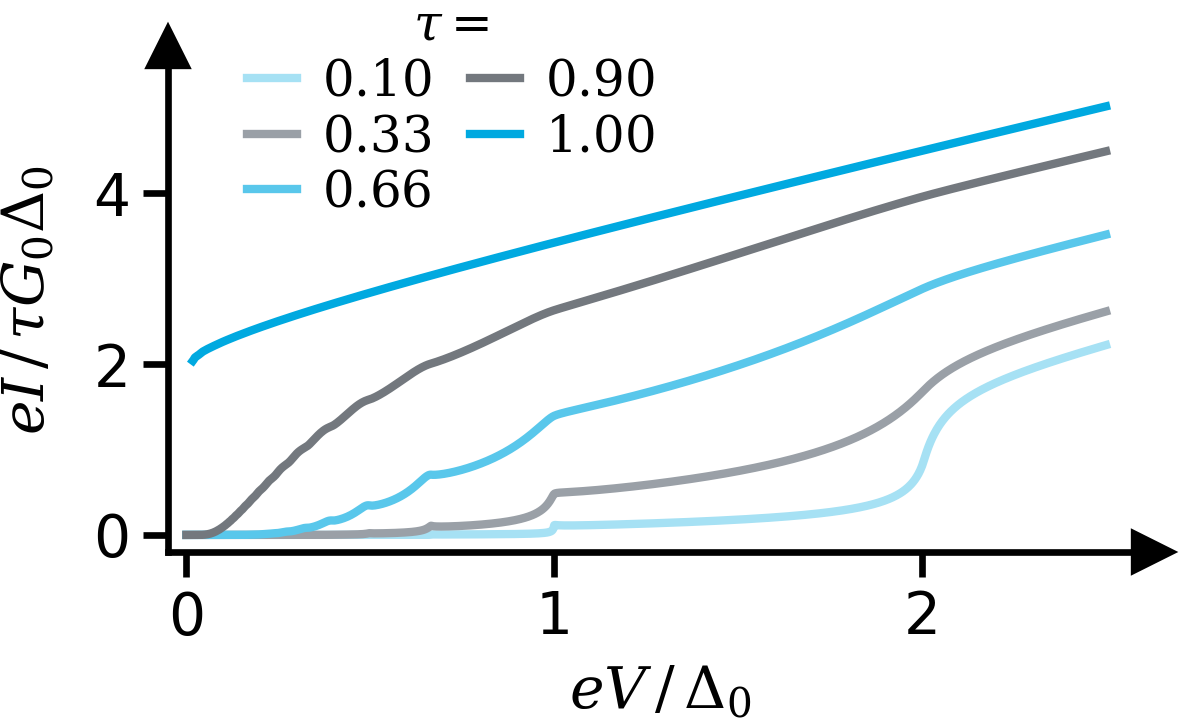

In [17]:
for j, tau_j in enumerate(tau):
    fig, ax = sc.get_figure(figsize=figsize)

    for i, tau_i in enumerate(tau[: j + 1]):
        ax.plot(
            V_mV / Delta_meV,
            I[i, :] / tau_i,
            color=colors[4 - i],
            zorder=i,
        )

    ax.set_ylim(-0.2, 5.7)
    ax.set_xlim(-0.05, None)

    for i, tau_i in enumerate(tau):
        ax.plot(
            [],
            [],
            color=colors[4 - i],
            label=f"${tau_i:.2f}$",
        )
    ax.legend(
        title="$\\tau = $",
        loc="upper left",
        ncols=2,
        handlelength=1.0,
        columnspacing=0.75,
        frameon=False,
        fontsize=6,
        title_fontsize=6,
        bbox_to_anchor=(0.05, 1.15),
        borderpad=0.1,  # reduces padding inside the legend box
        labelspacing=0.15,  # reduces vertical spacing between items
        handletextpad=0.5,  # reduces spacing between line and label
    )

    ylabel = "$eI\\,/\\,\\tau G_0\\Delta_0$"
    xlabel = "$eV\\,/\\,\\Delta_0$"
    title = f"theory/meso/ha-iv-{j}"

    sc.theory_layout(fig, ax, title, xlabel, ylabel)

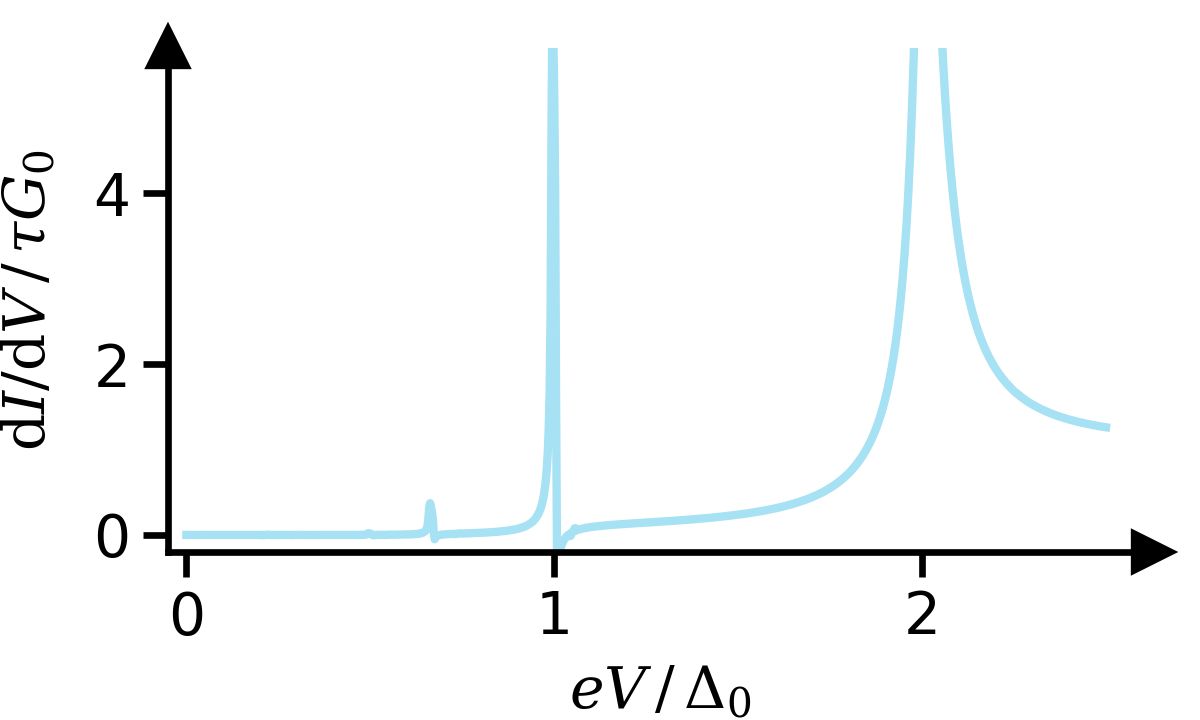

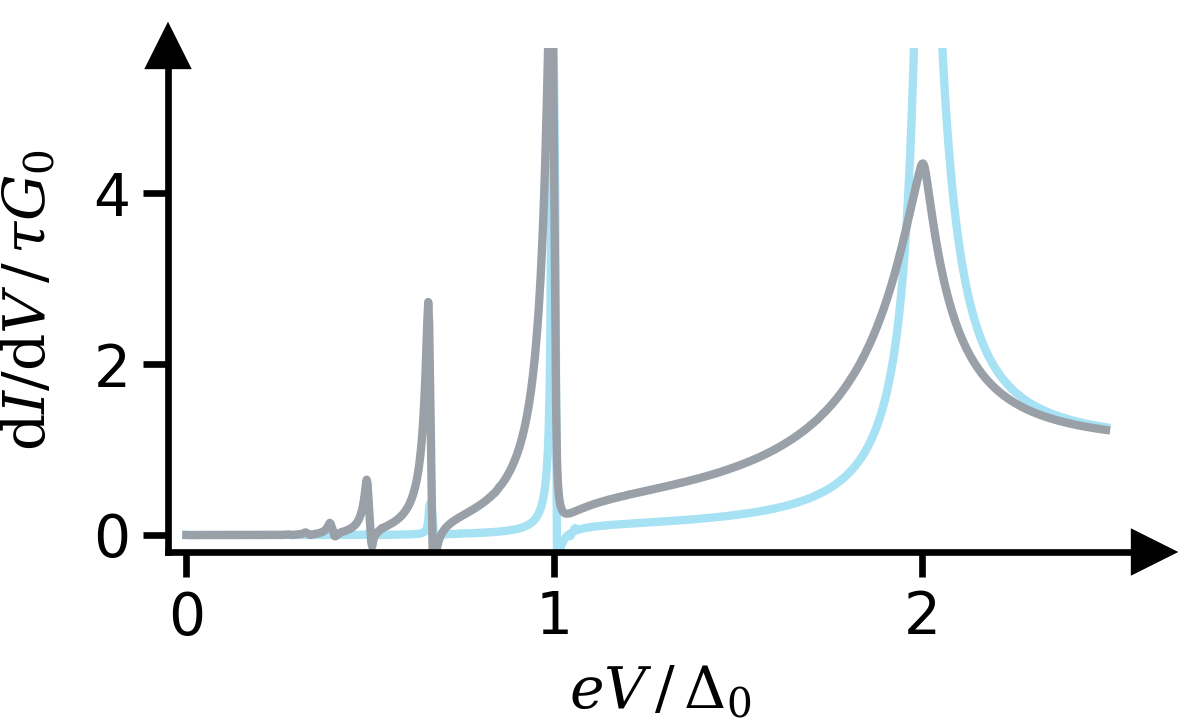

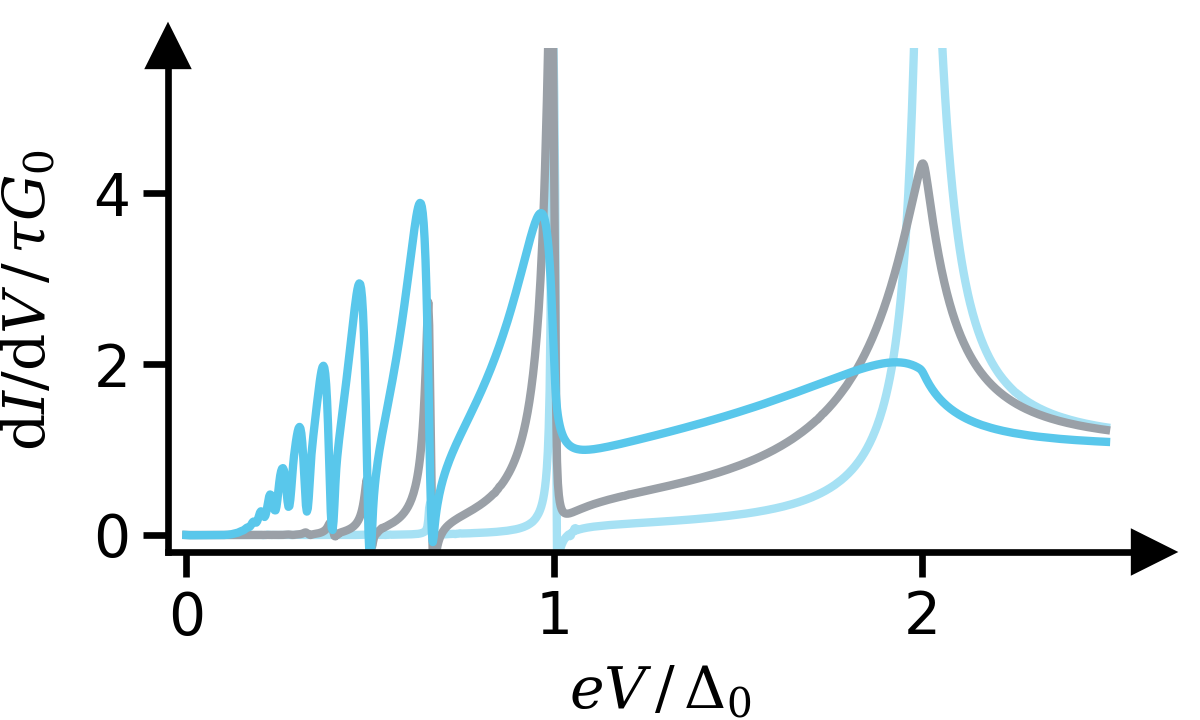

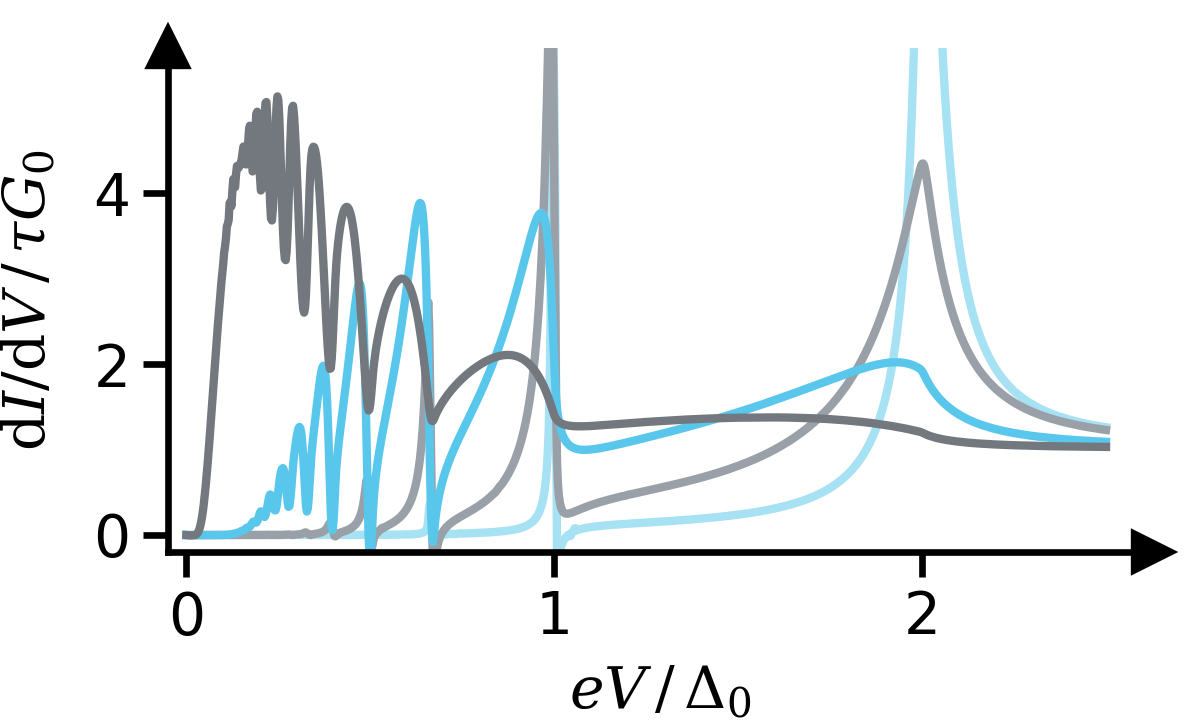

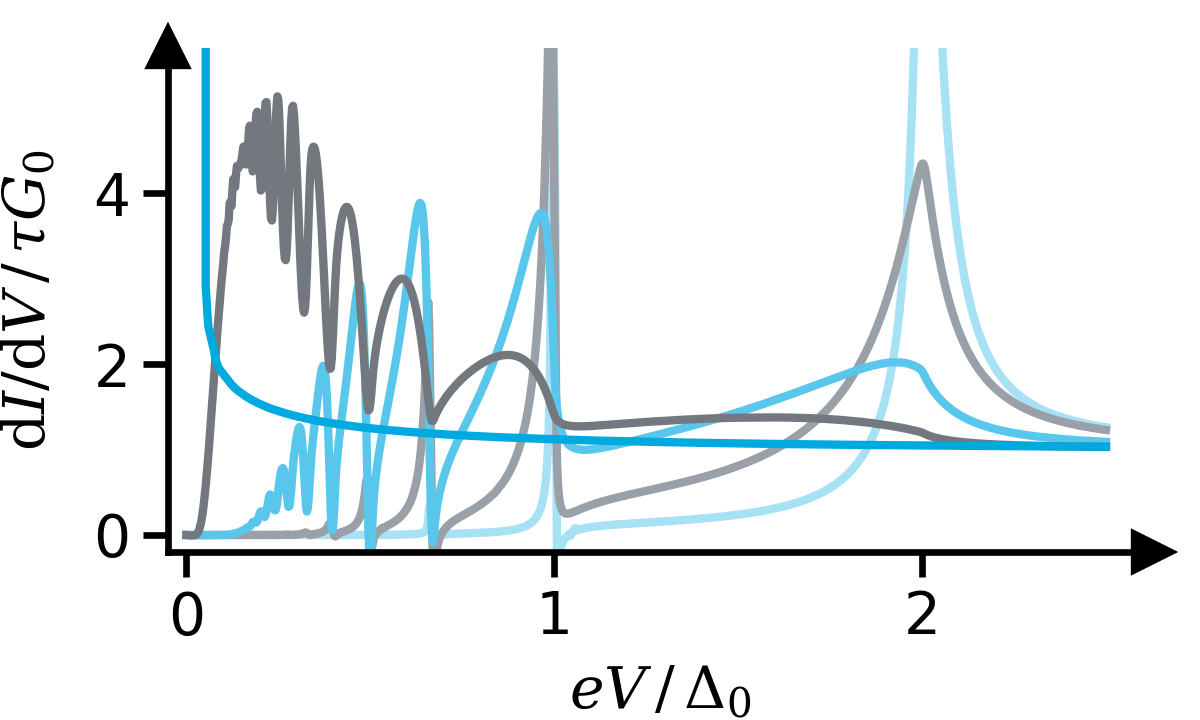

In [18]:
for j, tau_j in enumerate(tau):
    fig, ax = sc.get_figure(figsize=figsize)

    for i, tau_i in enumerate(tau[: j + 1]):
        ax.plot(
            V_mV / Delta_meV,
            dIdV[i, :] / tau_i,
            color=colors[4 - i],
            zorder=i,
            label=f"$\\tau={tau_i:.2f}$",
        )

    ax.set_ylim(-0.2, 5.7)
    ax.set_xlim(-0.05, None)

    ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,\\tau G_0$"
    xlabel = "$eV\\,/\\,\\Delta_0$"
    title = f"theory/meso/ha-didv-{i}"

    sc.theory_layout(fig, ax, title, xlabel, ylabel)

# fcs-current

In [19]:
V = np.linspace(0, 3.5, 351)
tau = np.array([0.9, 0.66, 0.33, 0.1])
tau = np.array([0.9, 0.66, 0.33])
M = np.arange(1, 11, 1)

I = np.empty((tau.shape[0], V.shape[0], M.shape[0] + 1))
dIdV = np.copy(I)

Delta_meV = 0.180
gamma_meV = 0.0
T_K = 0.0

from tqdm import tqdm

for i, tau_i in enumerate(tqdm(tau)):
    I[i, :, :] = sc.get_I_fcs_nA(
        V_mV=V * Delta_meV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    ) / (tau_i * G0_muS * Delta_meV)

dIdV = np.gradient(I, V, axis=1)

I[0, 11, 0] = (I[0, 10, 0] + I[0, 13, 0]) / 2
I[0, 12, 0] = (I[0, 11, 0] + I[0, 13, 0]) / 2

100%|██████████| 3/3 [00:00<00:00, 336.05it/s]


/Users/oliver/Documents/cryolab/.venv/lib/python3.13/site-packages/colorspacious/ciecam02.py:333: RuntimeWarning: invalid value encountered in divide
  t = (C


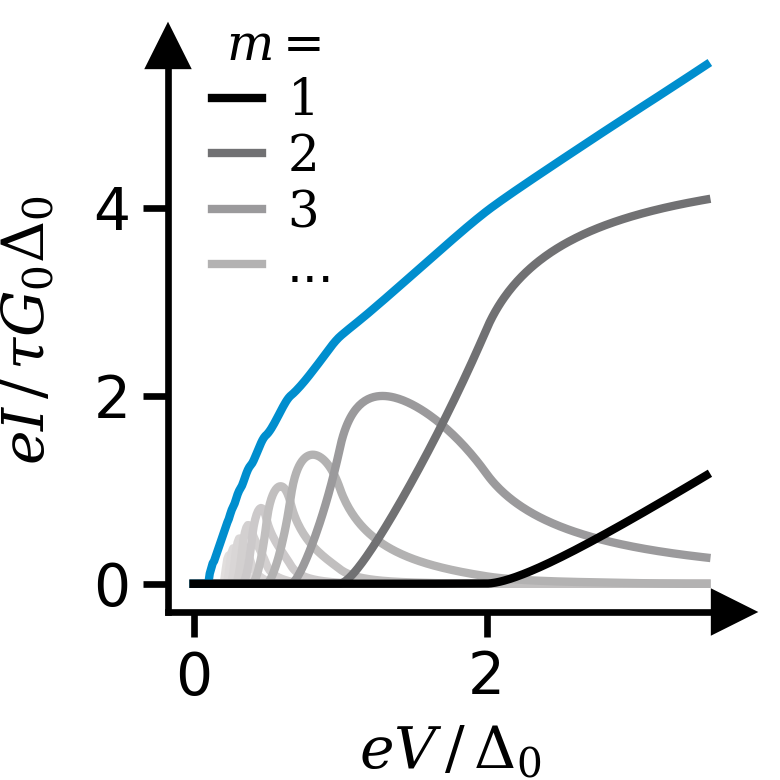

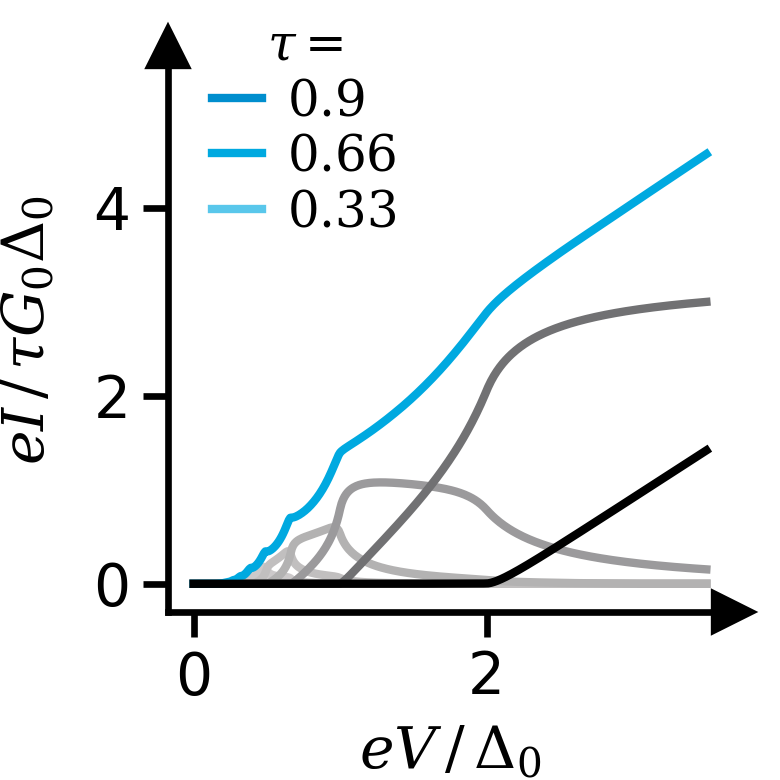

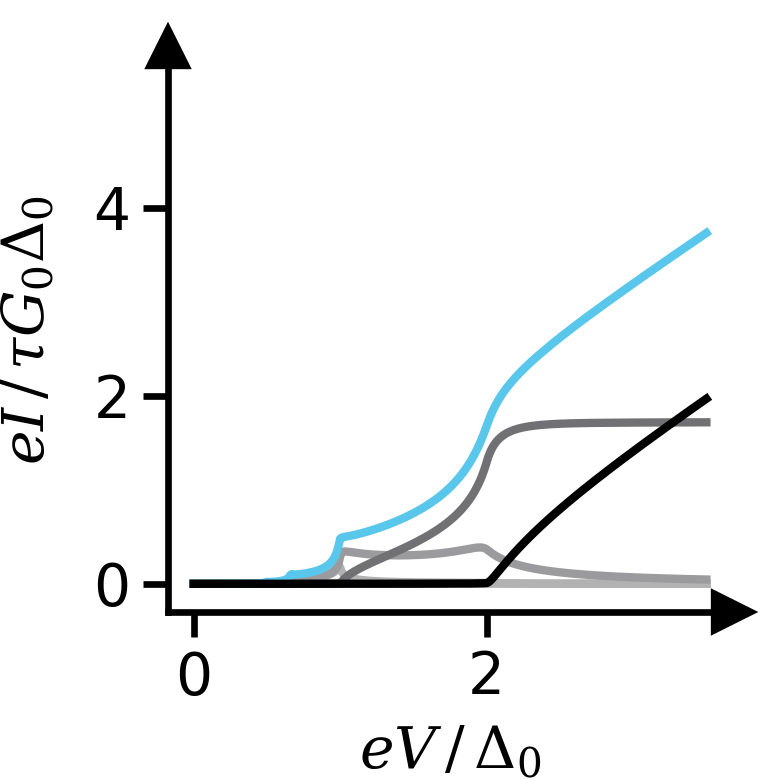

In [20]:
figsize = (1.3, 1.3)
from superconductivity.style.cpd5 import cmap_tinted_black_to_white

grey = cmap_tinted_black_to_white(sc.seegrau100)

for i_tau, tau_i in enumerate(tau):

    fig, ax = sc.get_figure(
        figsize=figsize,
        padding=(0.2, 0.2),
    )

    ax.plot(
        V,
        I[i_tau, :, 0],
        # color=seeblau100,
        color=sc.seeblau[i_tau],
        zorder=10,
    )

    for i, m in enumerate(M):
        ax.plot(
            V,
            I[i_tau, :, m],
            color=grey(1 - 1 / (i + 1)),
            zorder=10 - i,
            label=f"{m}",
        )

    if tau_i == tau[0]:
        index = 3
        handles, labels = [], []
        for i, m in enumerate(M[:index]):
            line_handle = Line2D([0], [0], color=grey(1 - 1 / (i + 1)), linestyle="-")
            label = f"${m}$"
            handles.append(line_handle)
            labels.append(label)

        line_handle = Line2D([0], [0], color=grey(1 - 1 / (index + 1)), linestyle="-")
        label = f"..."
        handles.append(line_handle)
        labels.append(label)

        ax.legend(
            title="$m=$",
            handles=handles,
            labels=labels,
            handlelength=1.0,
            loc="upper left",
            frameon=False,
            fontsize=6,
            title_fontsize=6,
            bbox_to_anchor=(0.025, 1.1),
            # bbox_to_anchor=(1.0, 1.15),
            borderpad=0.1,  # reduces padding inside the legend box
            labelspacing=0.15,  # reduces vertical spacing between items
            handletextpad=0.5,  # reduces spacing between line and label
        )

    if tau_i == tau[1]:
        handles, labels = [], []
        for ii_tau, tau_ii in enumerate(tau):
            line_handle = Line2D([0], [0], color=sc.seeblau[ii_tau], linestyle="-")
            label = f"${tau_ii}$"
            handles.append(line_handle)
            labels.append(label)

            ax.legend(
                title="$\\tau=$",
                handles=handles,
                labels=labels,
                handlelength=1.0,
                loc="upper left",
                frameon=False,
                fontsize=6,
                title_fontsize=6,
                bbox_to_anchor=(0.025, 1.1),
                # bbox_to_anchor=(1.0, 1.15),
                borderpad=0.1,  # reduces padding inside the legend box
                labelspacing=0.15,  # reduces vertical spacing between items
                handletextpad=0.5,  # reduces spacing between line and label
            )

    ax.set_ylim(-0.3, 5.7)

    ylabel = "$eI\\,/\\,\\tau G_0\\Delta_0$"
    xlabel = "$eV\\,/\\,\\Delta_0$"
    title = f"theory/meso/fcs-{int(tau_i*100):03d}"

    sc.theory_layout(fig, ax, title, xlabel, ylabel)

In [21]:
V1 = np.linspace(0.002, 1.0, 500)
V2 = np.linspace(1.0, 3.5, 251)
V3 = np.linspace(3.6, 10, 65)
V = np.concatenate((V1, V2, V3))
tau = np.array([1.0, 0.9, 0.8, 0.66])
tau = np.array([1.0, 0.9, 0.66, 0.33])
# tau = np.array([0.99, 0.9, 0.8, 0.66])
M = np.arange(1, 11, 1)

I_fcs = np.empty((tau.shape[0], V.shape[0], M.shape[0] + 1))
dIdV_fcs = np.copy(I_fcs)
d2IdV2_fcs = np.copy(I_fcs)

I_ha = np.empty((tau.shape[0], V.shape[0]))
dIdV_ha = np.copy(I_ha)
d2IdV2_ha = np.copy(I_ha)

Delta_meV = 0.180
gamma_meV = 0.0
T_K = 0.0

for i, tau_i in enumerate(tau):
    I_1_fcs = sc.get_I_fcs_nA(
        V_mV=V1 * Delta_meV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    ) / (G0_muS * Delta_meV)

    I_2_fcs = sc.get_I_fcs_nA(
        V_mV=V2 * Delta_meV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    ) / (G0_muS * Delta_meV)

    I_3_fcs = sc.get_I_fcs_nA(
        V_mV=V3 * Delta_meV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    ) / (G0_muS * Delta_meV)

    dIdV_1_fcs = np.gradient(I_1_fcs, V1, axis=0)
    dIdV_2_fcs = np.gradient(I_2_fcs, V2, axis=0)
    dIdV_3_fcs = np.gradient(I_3_fcs, V3, axis=0)

    d2IdV2_1_fcs = np.gradient(dIdV_1_fcs, V1, axis=0)
    d2IdV2_2_fcs = np.gradient(dIdV_2_fcs, V2, axis=0)
    d2IdV2_3_fcs = np.gradient(dIdV_3_fcs, V3, axis=0)

    I_fcs[i, :, :] = np.concatenate((I_1_fcs, I_2_fcs, I_3_fcs), axis=0)
    dIdV_fcs[i, :, :] = np.concatenate((dIdV_1_fcs, dIdV_2_fcs, dIdV_3_fcs), axis=0)
    d2IdV2_fcs[i, :, :] = np.concatenate(
        (d2IdV2_1_fcs, d2IdV2_2_fcs, d2IdV2_3_fcs), axis=0
    )

    I_1_ha = sc.get_I_ha_nA(
        V_mV=V1 * Delta_meV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    ) / (G0_muS * Delta_meV)

    I_2_ha = sc.get_I_ha_nA(
        V_mV=V2 * Delta_meV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    ) / (G0_muS * Delta_meV)

    I_3_ha = sc.get_I_ha_nA(
        V_mV=V3 * Delta_meV,
        Delta_meV=Delta_meV,
        tau=tau_i,
        T_K=T_K,
        gamma_meV=gamma_meV,
    ) / (G0_muS * Delta_meV)

    dIdV_1_ha = np.gradient(I_1_ha, V1, axis=0)
    dIdV_2_ha = np.gradient(I_2_ha, V2, axis=0)
    dIdV_3_ha = np.gradient(I_3_ha, V3, axis=0)

    d2IdV2_1_ha = np.gradient(dIdV_1_ha, V1, axis=0)
    d2IdV2_2_ha = np.gradient(dIdV_2_ha, V2, axis=0)
    d2IdV2_3_ha = np.gradient(dIdV_3_ha, V3, axis=0)

    I_ha[i, :] = np.concatenate((I_1_ha, I_2_ha, I_3_ha), axis=0)
    dIdV_ha[i, :] = np.concatenate((dIdV_1_ha, dIdV_2_ha, dIdV_3_ha), axis=0)
    d2IdV2_ha[i, :] = np.concatenate((d2IdV2_1_ha, d2IdV2_2_ha, d2IdV2_3_ha), axis=0)

In [22]:
color_strings = [
    "seegrau",
    "seeblau",
    "peach",
    "petrol",
    "pinky",
    "seegruen",
    "karpfenblau",
    "bordeaux",
    "seeblau",
]
color_shades = ["100", "80", "65", "35", "20"]
permutation = [
    "standard",
    "standard",
    "standard",
    "standard",
    "standard",
    "standard",
    "standard",
    "standard",
    "magenta",
]
M = np.arange(1, 9)

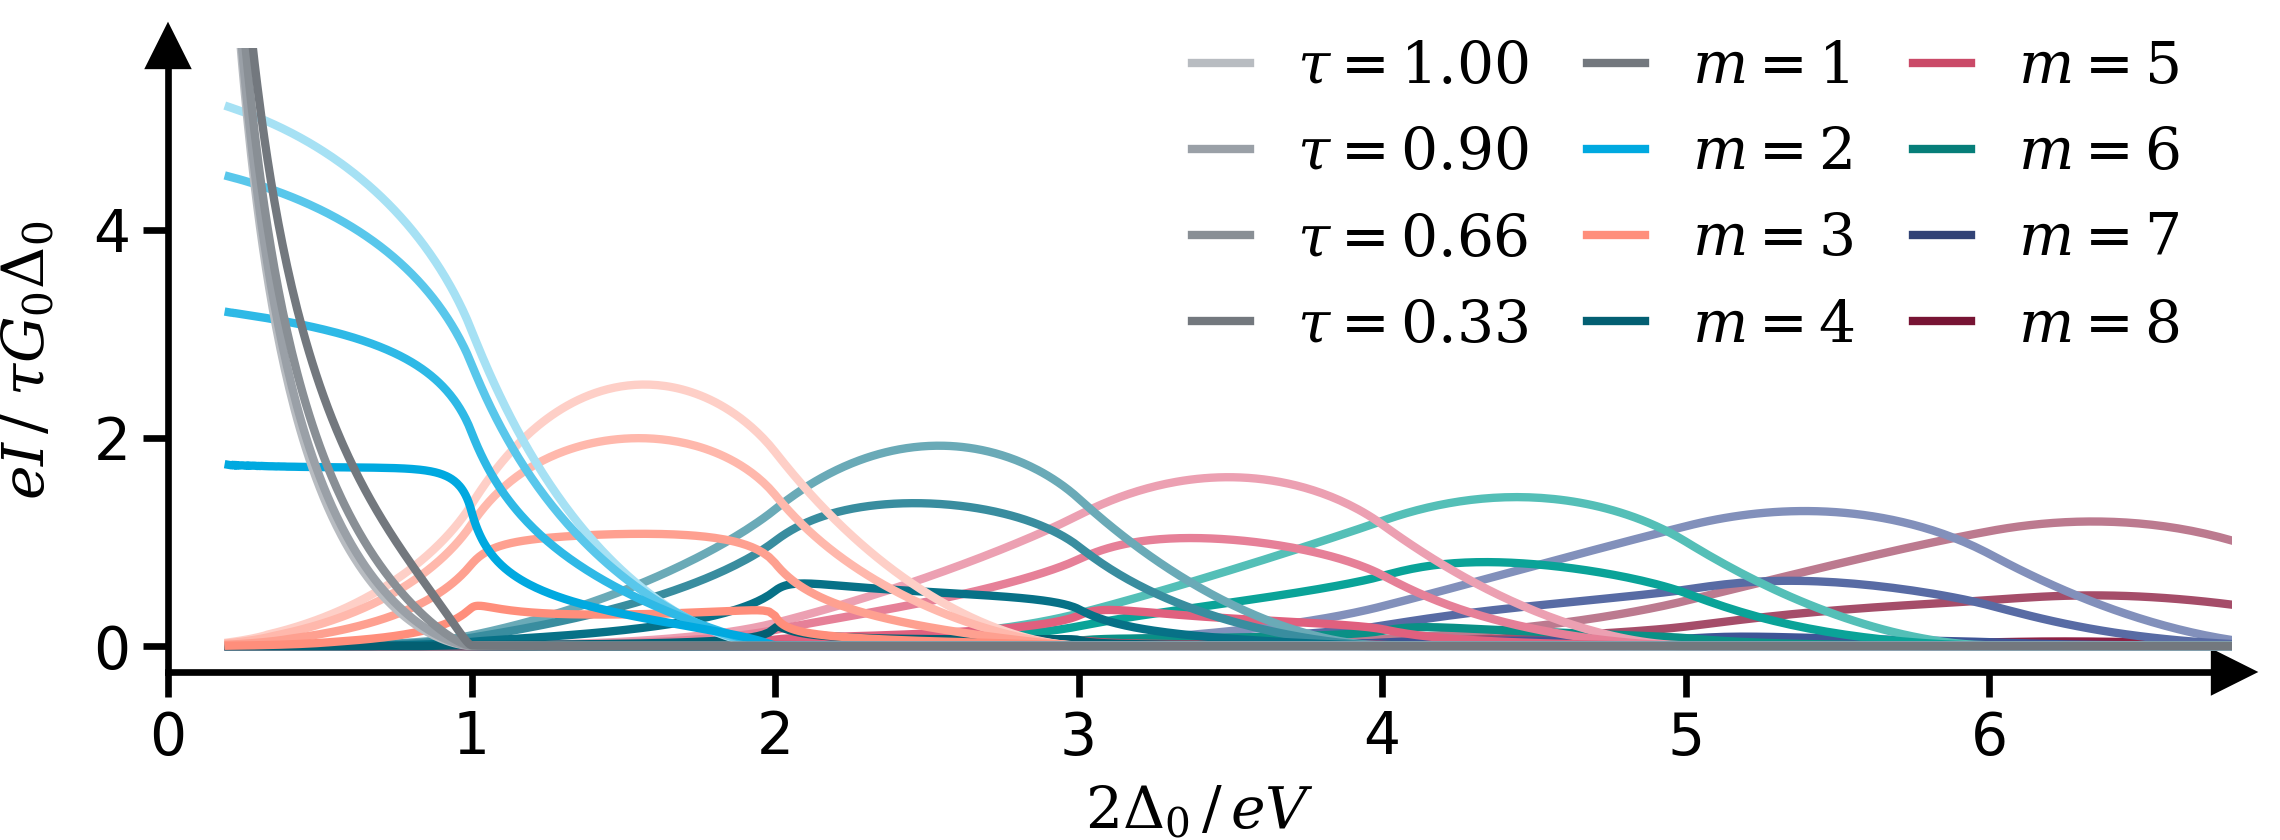

In [23]:
fig, ax = sc.get_figure(figsize=(3.8, 1.4))

for i_tau, tau_i in enumerate(tau):
    if i_tau < 4:
        for i_m, m in enumerate(M):
            ax.plot(
                2 / V,
                I_fcs[i_tau, :, m] / tau_i,
                color=sc.get_color(
                    palette=color_strings[i_m],
                    shade=3 - i_tau,
                    permutation=permutation[i_m],
                ),
                zorder=i_tau + (10 - i_m) * 10,
            )

handles, labels = [], []
for i_tau, tau_i in enumerate(tau):
    line_handle = Line2D(
        [0], [0], color=sc.get_color(palette="seegrau", shade=3 - i_tau), linestyle="-"
    )
    label = f"$\\tau={tau_i:.2f}$"
    handles.append(line_handle)
    labels.append(label)

for i_m, m in enumerate(M):
    line_handle = Line2D(
        [0], [0], color=sc.get_color(palette=color_strings[i_m], shade=0), linestyle="-"
    )
    label = f"$m={m}$"
    handles.append(line_handle)
    labels.append(label)

ax.legend(
    handles=handles,
    labels=labels,
    handlelength=1.0,
    loc="upper right",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=3,
    columnspacing=1.0,
    bbox_to_anchor=(1.0, 1.1),
)


ax.set_xlim(0, 6.8)
ax.set_ylim(-0.25, 5.75)

# ax.set_xticks([1, 3, 5, 7])
xlabel = "$2\\Delta_0\\,/\\,eV$"

ylabel = "$eI\\,/\\,\\, \\tau G_0\\Delta_0$"
title = f"theory/meso/fcs-iv-m-inv-wide"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

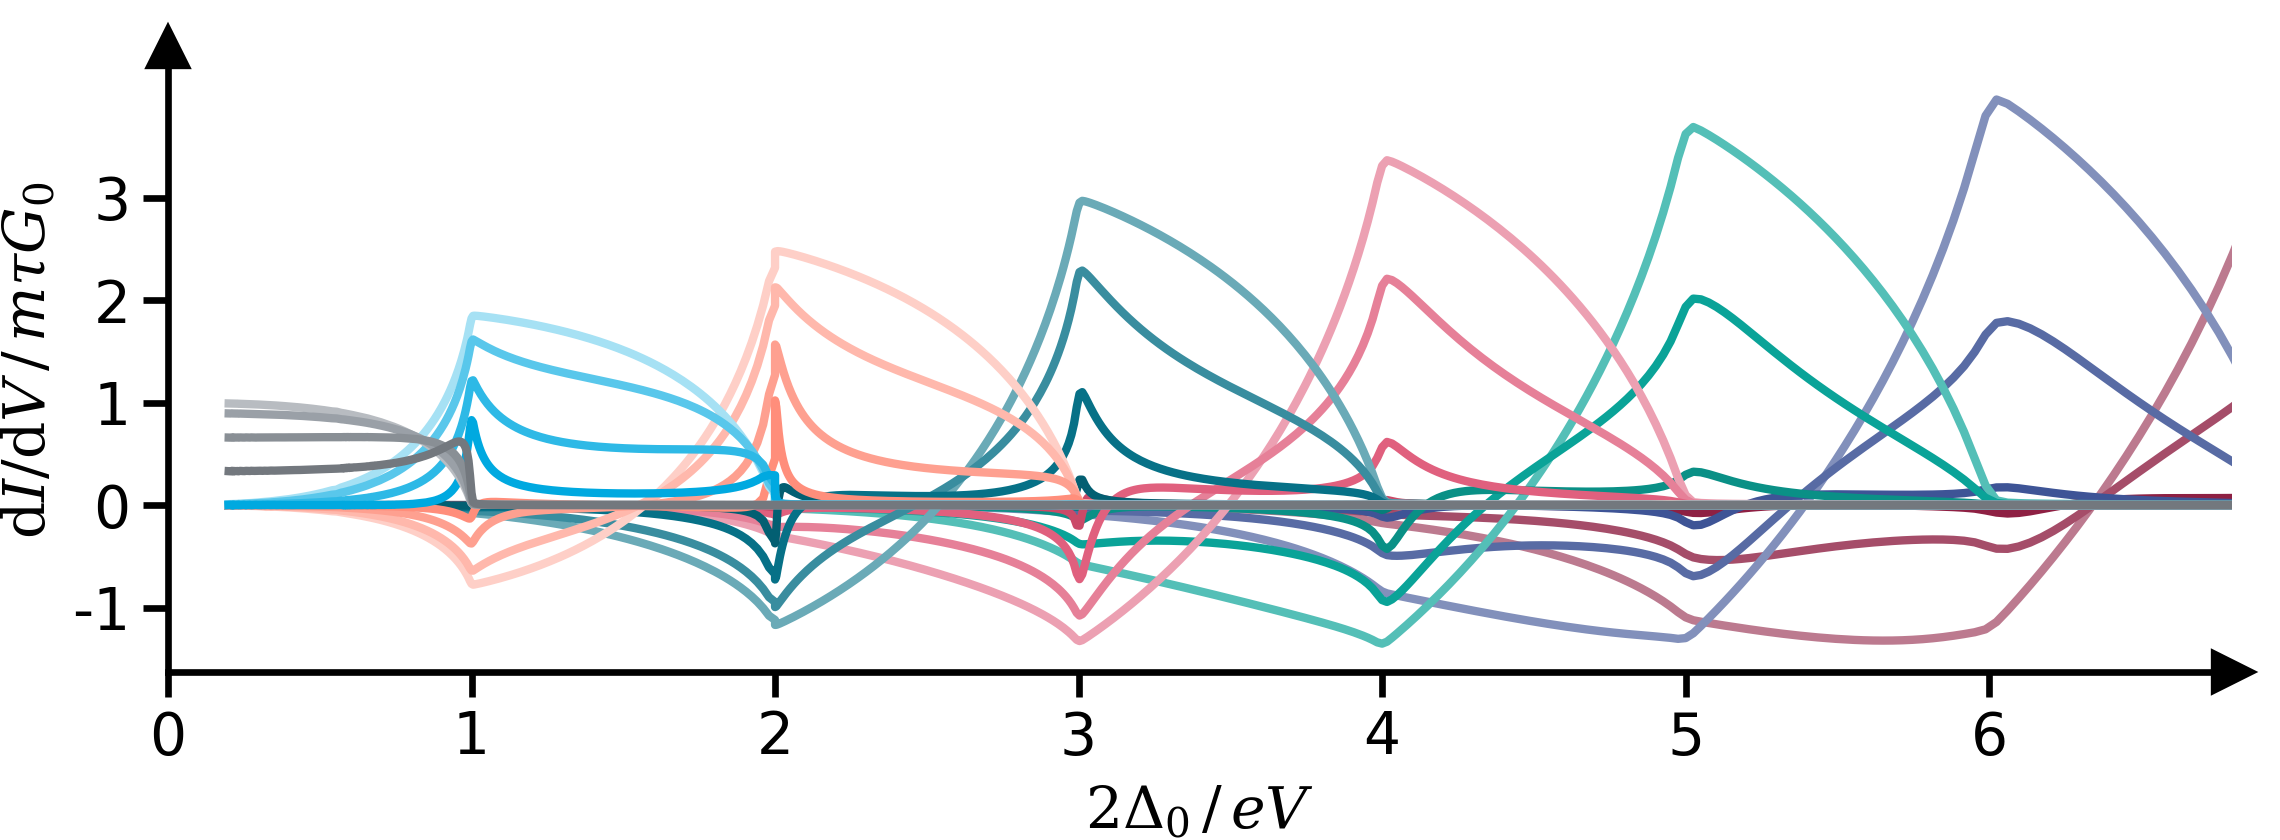

In [24]:
fig, ax = sc.get_figure(figsize=(3.8, 1.4))

for i_tau, tau_i in enumerate(tau):
    if i_tau < 4:
        for i_m, m in enumerate(M):
            ax.plot(
                2 / V,
                dIdV_fcs[i_tau, :, m] / m,
                color=sc.get_color(
                    palette=color_strings[i_m],
                    shade=3 - i_tau,
                    permutation=permutation[i_m],
                ),
                zorder=i_tau + (10 - i_m) * 10,
            )

ax.set_xlim(0, 6.8)
# ax.set_ylim(-1.5, 3.75)
ax.set_yticks([-1, 0, 1, 2, 3])

# ax.set_xticks([1, 3, 5, 7])
xlabel = "$2\\Delta_0\\,/\\,eV$"

ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,m\\tau G_0$"
title = f"theory/meso/fcs-didv-m-inv-wide"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

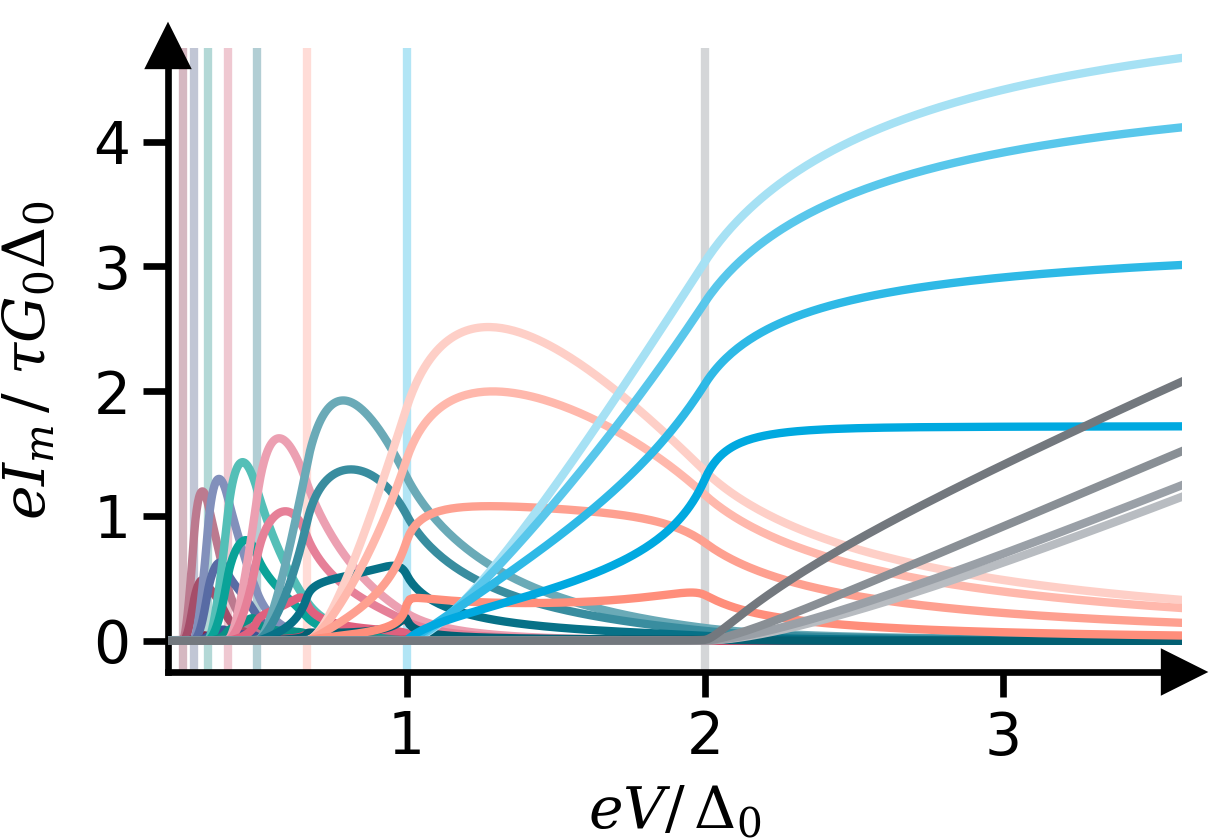

In [25]:
fig, ax = sc.get_figure(figsize=(2.05, 1.4))

for i_tau, tau_i in enumerate(tau):
    if i_tau < 4:
        for i_m, m in enumerate(M):
            ax.plot(
                V,
                I_fcs[i_tau, :, m] / tau_i,
                color=sc.get_color(
                    palette=color_strings[i_m],
                    shade=3 - i_tau,
                    permutation=permutation[i_m],
                ),
                zorder=i_tau + (10 - i_m) * 10,
            )

ylim = -0.25, 4.75
xlim = 0.2, 3.6
ax.set_ylim(ylim)
ax.set_xlim(xlim)

for i_m, m in enumerate(M):
    ax.vlines(
        2 / m,
        ymin=ylim[0],
        ymax=ylim[1],
        color=sc.get_color(
            palette=color_strings[i_m],
            shade=0,
            permutation=permutation[i_m],
        ),
        alpha=0.3,
    )


# ax.set_xticks([1, 3, 5, 7])
xlabel = "$eV/\\,\\Delta_0$"

ylabel = "$eI_m\\,/\\,\\, \\tau G_0\\Delta_0$"
title = f"theory/meso/fcs-iv-m"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

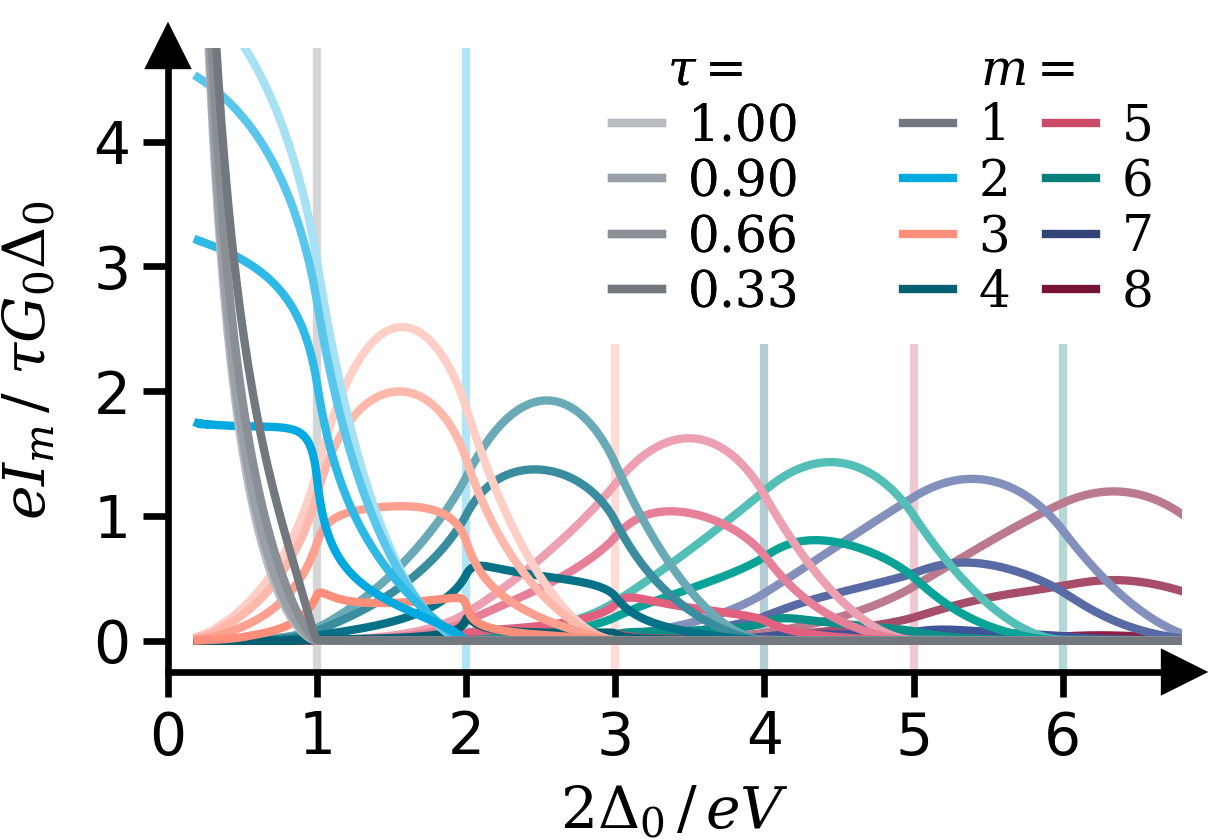

In [26]:
fig, ax = sc.get_figure(figsize=(2.05, 1.4))

for i_tau, tau_i in enumerate(tau):
    if i_tau < 4:
        for i_m, m in enumerate(M):
            ax.plot(
                2 / V,
                I_fcs[i_tau, :, m] / tau_i,
                color=sc.get_color(
                    palette=color_strings[i_m],
                    shade=3 - i_tau,
                    permutation=permutation[i_m],
                ),
                zorder=i_tau + (10 - i_m) * 10,
            )

handles, labels = [], []
for i_m, m in enumerate(M):
    line_handle = Line2D(
        [0], [0], color=sc.get_color(palette=color_strings[i_m], shade=0), linestyle="-"
    )
    label = f"${m}$"
    handles.append(line_handle)
    labels.append(label)

legend_m = ax.legend(
    title="$m=$",
    handles=handles,
    labels=labels,
    ncols=2,
    handlelength=1.0,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    columnspacing=0.75,
    # bbox_to_anchor=(0.025, 1.1),
    bbox_to_anchor=(1.0, 1.05),
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.15,  # reduces vertical spacing between items
    handletextpad=0.5,  # reduces spacing between line and label
)
ax.add_artist(legend_m)


handles, labels = [], []
for i_tau, tau_i in enumerate(tau):
    line_handle = Line2D(
        [0], [0], color=sc.get_color(palette="seegrau", shade=3 - i_tau), linestyle="-"
    )
    label = f"${tau_i:.2f}$"
    handles.append(line_handle)
    labels.append(label)

legend_tau = ax.legend(
    title="$\\tau=$",
    handles=handles,
    labels=labels,
    ncols=1,
    handlelength=1.0,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    columnspacing=0.75,
    # bbox_to_anchor=(0.025, 1.1),
    bbox_to_anchor=(0.65, 1.05),
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.15,  # reduces vertical spacing between items
    handletextpad=0.5,  # reduces spacing between line and label
)
ax.add_artist(legend_tau)

ylim = -0.25, 4.75
xlim = 0, 6.8
ax.set_ylim(ylim)
ax.set_xlim(xlim)

for i_m, m in enumerate(M):
    if i_m < 2:
        ax.vlines(
            m,
            ymin=ylim[0],
            ymax=ylim[1],
            color=sc.get_color(
                palette=color_strings[i_m],
                shade=0,
                permutation=permutation[i_m],
            ),
            alpha=0.3,
        )
    else:
        ax.vlines(
            m,
            ymin=ylim[0],
            ymax=ylim[1] / 2,
            color=sc.get_color(
                palette=color_strings[i_m],
                shade=0,
                permutation=permutation[i_m],
            ),
            alpha=0.3,
        )

ax.set_xticks([0, 1, 2, 3, 4, 5, 6])

xlabel = "$2\\Delta_0\\,/\\,eV$"

ylabel = "$eI_m\\,/\\,\\, \\tau G_0\\Delta_0$"
title = f"theory/meso/fcs-iv-m-inv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

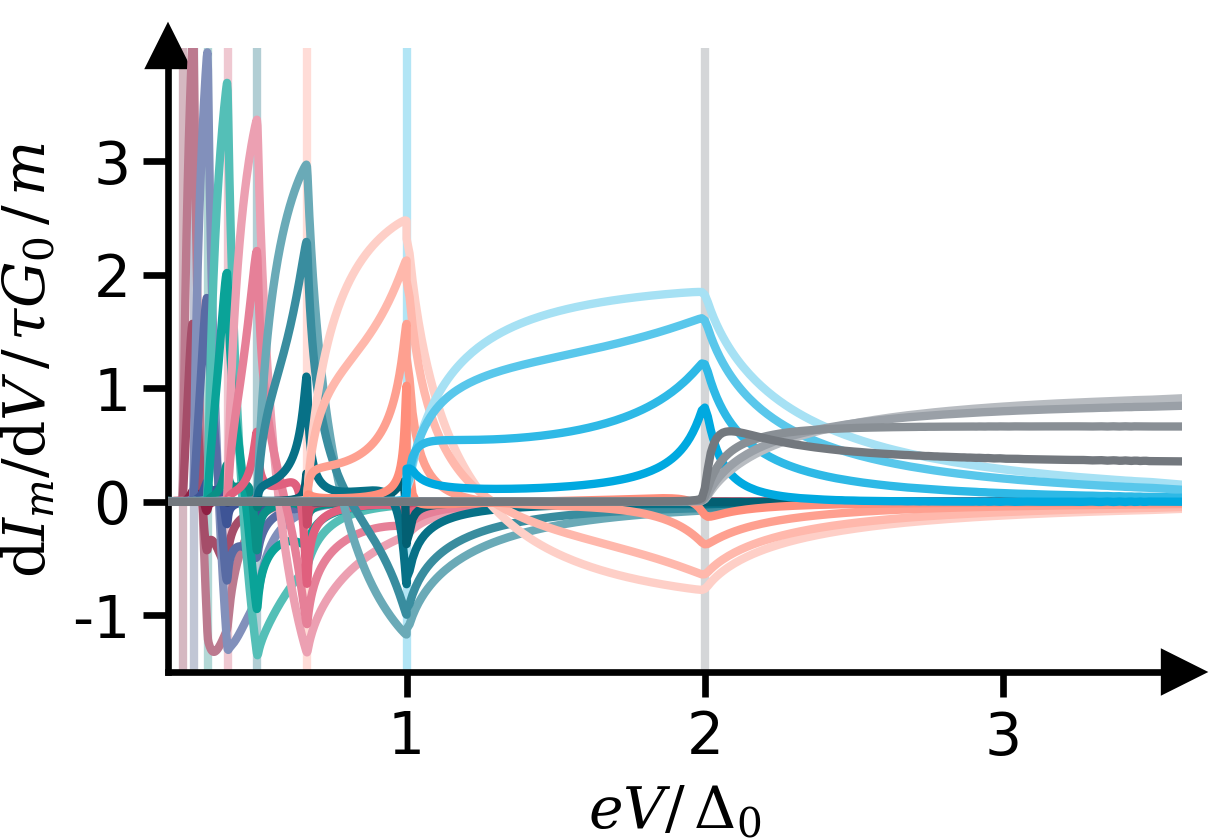

In [27]:
fig, ax = sc.get_figure(figsize=(2.05, 1.4))

for i_tau, tau_i in enumerate(tau):
    if i_tau < 4:
        for i_m, m in enumerate(M):
            ax.plot(
                V,
                dIdV_fcs[i_tau, :, m] / m,
                color=sc.get_color(
                    palette=color_strings[i_m],
                    shade=3 - i_tau,
                    permutation=permutation[i_m],
                ),
                zorder=i_tau + (10 - i_m) * 10,
            )

xlim = 0.2, 3.6
ylim = -1.5, 4
ax.set_ylim(ylim)
ax.set_xlim(xlim)

for i_m, m in enumerate(M):
    ax.vlines(
        2 / m,
        ymin=ylim[0],
        ymax=ylim[1],
        color=sc.get_color(
            palette=color_strings[i_m],
            shade=0,
            permutation=permutation[i_m],
        ),
        alpha=0.3,
    )

ax.set_yticks([-1, 0, 1, 2, 3])

xlabel = "$eV/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I_m/\\mathrm{d}V\\,/\\,\\tau G_0\\,/\\,m$"
title = f"theory/meso/fcs-didv-m"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

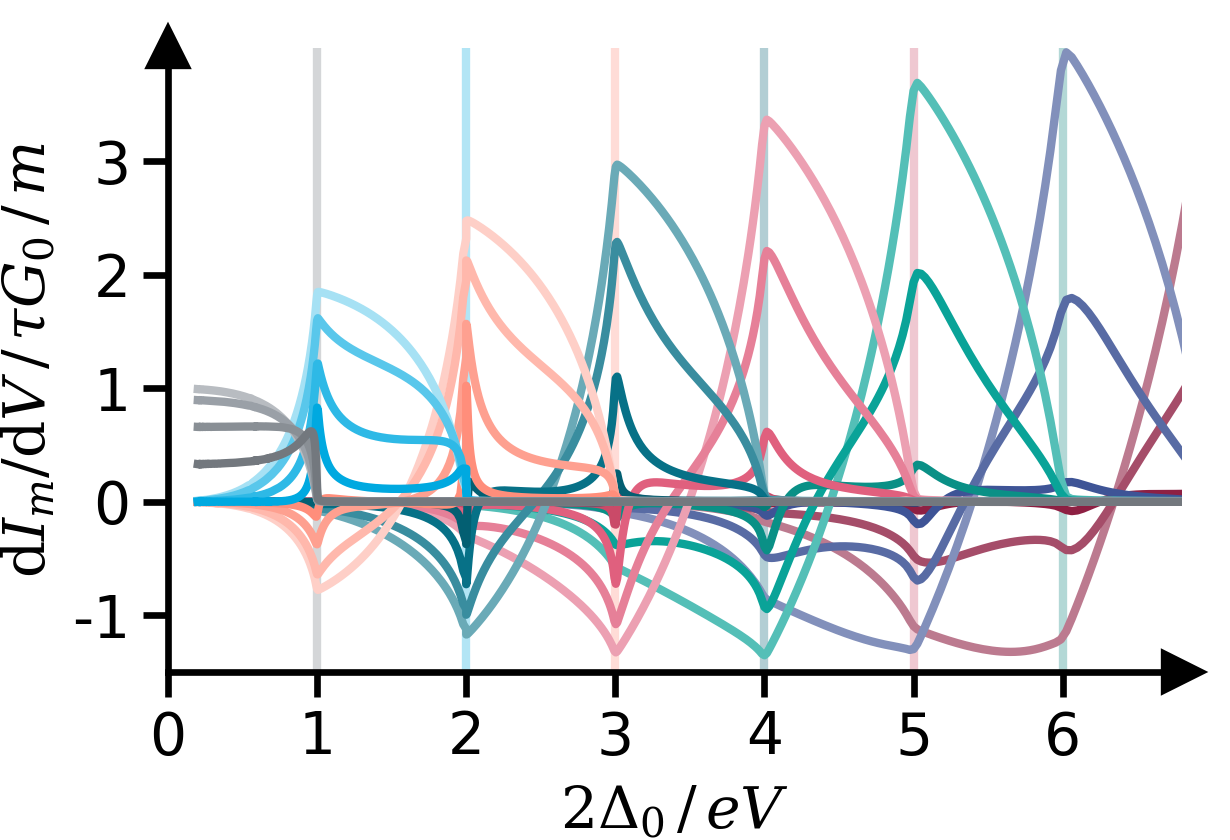

In [28]:
fig, ax = sc.get_figure(figsize=(2.05, 1.4))

for i_tau, tau_i in enumerate(tau):
    if i_tau < 4:
        for i_m, m in enumerate(M):
            ax.plot(
                2 / V,
                dIdV_fcs[i_tau, :, m] / m,
                color=sc.get_color(
                    palette=color_strings[i_m],
                    shade=3 - i_tau,
                    permutation=permutation[i_m],
                ),
                zorder=i_tau + (10 - i_m) * 10,
            )

xlim = 0, 6.8
ylim = -1.5, 4
ax.set_ylim(ylim)
ax.set_xlim(xlim)

for i_m, m in enumerate(M):
    ax.vlines(
        m,
        ymin=ylim[0],
        ymax=ylim[1],
        color=sc.get_color(
            palette=color_strings[i_m],
            shade=0,
            permutation=permutation[i_m],
        ),
        alpha=0.3,
    )

ax.set_xticks([0, 1, 2, 3, 4, 5, 6])
ax.set_yticks([-1, 0, 1, 2, 3])

xlabel = "$2\\Delta_0\\,/\\,eV$"
ylabel = "$\\mathrm{d}I_m/\\mathrm{d}V\\,/\\,\\tau G_0\\,/\\,m$"
title = f"theory/meso/fcs-didv-m-inv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)